#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/NO2_Land_Grid_Bangkok.csv")
wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Wind_NO2_MeanDaily_Bangkok_ADM1.csv")


#2. Class Definition

In [ ]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

#Untuk Membangun Fourier Feature dengan Banyak Initial Sigma
class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)


#Untuk Membangun Fourier Feature pad Satu Initial Sigma
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Pakai RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='tanh',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim, activation = 'softplus')


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  #X = [t, x, y] harus tensor
        X = tf.reshape(X, (-1, 3))  # Memastikan Dimensi input (batch_size, features) untuk [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z) #melakukan fourier freatures dengan multisigma
        for i in range(self.num_hidden_layers): #hidden layers
            Z = self.hidden[i](Z)
        return self.out(Z)

class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



#self disini adalah modelnya
def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]
    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

#Arsitektur dari H-PINN (inherit dari arsitektur PINN)
class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        return super().trainable_variables + [self.lambd]

#Cara optimasi dari HPINN
class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param,
                           X, u, W_u, W_v,
                           N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None,
                               modified=False, **kwargs):

        self.changed = False
        self.lambd_list = []

        # ================================
        # Forward optimization (NO batching, full dataset)
        # ================================
        print("\n\nForward optimization (full dataset)")
        self.iter = 0
        self.hist = []
        import time
        start_time = time.time()

        @tf.function
        def train_step_fwd():
            with tf.GradientTape() as tape:
                loss, _ = self.loss_fn(X, u, W_u, W_v) # Pass W_u, W_v here
            grads = tape.gradient(loss, self.model.trainable_variables)
            optim_fwd.apply_gradients(zip(grads, self.model.trainable_variables))
            return loss

        if N_fwd is not None:
            N_fwd = int(N_fwd)
            for _ in range(N_fwd):
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
            print(f"{N_fwd} forward iterations reached.")
        elif min_loss_fwd is not None:
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                if self.current_loss < min_loss_fwd:
                    print(f"Forward loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_fwd is not None:
            stop_after = time.time() + timeout_fwd
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                print(f"Iteration {self.iter}, Loss: {self.current_loss}")
                if time.time() > stop_after:
                    print(f"Forward timeout reached ({time.time()-start_time:.1f}s)")
                    break

        # ================================
        # Add PDE parameters
        # ================================
        self.model.add_param()
        self.changed = True
        print('\n\nFinding PDE parameters...')

        # ================================
        # Lambda penalty
        # ================================
        def lambda_penalty_hinge(lam=self.model.lambd, lam_min=1e-3, alpha=1e-2):
            return alpha * tf.square(tf.nn.relu(lam_min - lam))

        # ================================
        # Inverse optimization
        # ================================
        if modified:
            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param(self.t, self.x, self.y, W_u, W_v, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss
        else:
            @tf.function
            def train_step_param():
                with tf.GradientTape(persistent=True) as tape_lambd: # Make tape persistent
                    tape_lambd.watch(self.model.lambd)
                    loss = self.get_r(self.t, self.x, self.y, u, W_u, W_v) # Pass arguments here
                    loss += lambda_penalty_hinge(self.model.lambd, lam_min=1e-3, alpha=1e-2)
                grad_lambd = tape_lambd.gradient(loss, self.model.lambd)
                del tape_lambd # Delete tape when done
                optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                return loss

        def callback():
            lambd = self.model.lambd.numpy()
            self.model.lambd_list.append(lambd)
            if self.iter % 10 == 0:
                print(f"It {self.iter:05d}: loss = {self.current_loss:.3e} lambda = {lambd}")
            self.hist.append(self.current_loss)
            self.iter += 1

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        start_time = time.time()
        if N_param is not None:
            N_param = int(N_param)
            for _ in range(N_param):
                loss_callback()
            print(f"{N_param} inverse iterations reached.")
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print(f"Inverse loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print(f"Inverse timeout reached ({time.time()-start_time:.1f}s)")
                    break

    # ======================================================
    # Loss fn same as yours, but takes full dataset
    # ======================================================
    def loss_fn(self, X, u, Wu, Wv): # Added Wu, Wv here
        if self.changed:
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            r = self.get_r(t, x, y, u, Wu, Wv) # Pass arguments here
            loss = r
            return loss, r
        else:
            u_pred = self.model(X)
            loss = tf.reduce_mean(tf.square(u - u_pred))
            return loss, 0.0

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print(f"It {self.iter:05d}: l_u = {self.phi_0_b:.3e} loss = {self.current_loss:.3e}")
        self.hist.append(self.current_loss)
        self.iter += 1

# Pra-pemrosesan Data

In [ ]:
df.columns

Index(['date', 'mean', 'longitude', 'latitude'], dtype='object')

In [ ]:
wind

,date,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
0,2023-05-01,100.338864,13.676988,NaN,NaN,NaN,NaN
1,2023-05-01,100.338063,13.682278,-0.755996,1.169993,1.392987,302.868698
2,2023-05-01,100.338612,13.701442,NaN,NaN,NaN,NaN
3,2023-05-01,100.337941,13.708376,-0.755996,1.169993,1.392987,302.868698
4,2023-05-01,100.338148,13.721229,-0.755996,1.169993,1.392987,302.868698
...,...,...,...,...,...,...,...
1078935,2025-04-29,100.924874,13.819598,-0.815294,0.331706,0.880189,337.860854
1078936,2025-04-29,100.922257,13.827371,NaN,NaN,NaN,NaN
1078937,2025-04-29,100.930979,13.800684,NaN,NaN,NaN,NaN
1078938,2025-04-29,100.932461,13.807774,-0.815294,0.331706,0.880189,337.860854


In [ ]:
df

,date,mean,longitude,latitude
0,2023-05-01,NaN,100.338864,13.676988
1,2023-05-01,0.000144,100.338063,13.682278
2,2023-05-01,NaN,100.338612,13.701442
3,2023-05-01,0.000144,100.337941,13.708376
4,2023-05-01,0.000144,100.338148,13.721229
...,...,...,...,...
1078935,2025-04-29,0.000089,100.924874,13.819598
1078936,2025-04-29,NaN,100.922257,13.827371
1078937,2025-04-29,NaN,100.930979,13.800684
1078938,2025-04-29,0.000089,100.932461,13.807774


In [ ]:
wind.describe()

,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
count,1.078940e+06,1.078940e+06,1.003020e+06,1.003020e+06,1.003020e+06,1.003020e+06
mean,1.006277e+02,1.376989e+01,2.768018e-01,7.499333e-01,2.105402e+00,1.866070e+02
std,1.635927e-01,9.704283e-02,1.379507e+00,1.658528e+00,9.275282e-01,9.525569e+01
min,1.003361e+02,1.349963e+01,-4.674856e+00,-4.757746e+00,1.552426e-02,1.286865e-01
25%,1.004849e+02,1.370914e+01,-6.348260e-01,-5.604215e-01,1.455094e+00,7.402554e+01
50%,1.006265e+02,1.377089e+01,1.586177e-01,1.055008e+00,2.146151e+00,2.213204e+02
75%,1.007680e+02,1.384499e+01,1.245951e+00,1.960712e+00,2.754169e+00,2.619604e+02
max,1.009325e+02,1.395146e+01,5.253960e+00,6.101706e+00,6.105534e+00,3.599608e+02


In [ ]:
df.describe()

,mean,longitude,latitude
count,988509.000000,1.078940e+06,1.078940e+06
mean,0.000118,1.006277e+02,1.376989e+01
std,0.000056,1.635927e-01,9.704283e-02
min,0.000006,1.003361e+02,1.349963e+01
25%,0.000083,1.004849e+02,1.370914e+01
50%,0.000104,1.006265e+02,1.377089e+01
75%,0.000136,1.007680e+02,1.384499e+01
max,0.000740,1.009325e+02,1.395146e+01


## Pembersihan Data Polusi

In [ ]:
# df = no2_df.drop(columns=['Unnamed: 0'])
# df = df.drop(columns=['Unnamed: 0'])
# wind = wind.drop(columns=['Unnamed: 0'])

wind.dropna(inplace=True)
df.dropna(inplace = True)
df = df[df["mean"]>=0]

In [ ]:
wind

,date,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
1,2023-05-01,100.338063,13.682278,-0.755996,1.169993,1.392987,302.868698
3,2023-05-01,100.337941,13.708376,-0.755996,1.169993,1.392987,302.868698
4,2023-05-01,100.338148,13.721229,-0.755996,1.169993,1.392987,302.868698
6,2023-05-01,100.337116,13.747069,-0.803075,0.972524,1.261242,309.548640
7,2023-05-01,100.336273,13.758631,-0.803075,0.972524,1.261242,309.548640
...,...,...,...,...,...,...,...
1078932,2025-04-29,100.915276,13.942720,-0.804878,0.177327,0.824180,347.575309
1078934,2025-04-29,100.925230,13.807942,-0.815294,0.331706,0.880189,337.860854
1078935,2025-04-29,100.924874,13.819598,-0.815294,0.331706,0.880189,337.860854
1078938,2025-04-29,100.932461,13.807774,-0.815294,0.331706,0.880189,337.860854


In [ ]:
df

,date,mean,longitude,latitude
1,2023-05-01,0.000144,100.338063,13.682278
3,2023-05-01,0.000144,100.337941,13.708376
4,2023-05-01,0.000144,100.338148,13.721229
6,2023-05-01,0.000139,100.337116,13.747069
7,2023-05-01,0.000139,100.336273,13.758631
...,...,...,...,...
1078932,2025-04-29,0.000094,100.915276,13.942720
1078934,2025-04-29,0.000089,100.925230,13.807942
1078935,2025-04-29,0.000089,100.924874,13.819598
1078938,2025-04-29,0.000089,100.932461,13.807774


In [ ]:
wind.describe()

,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
count,1.003020e+06,1.003020e+06,1.003020e+06,1.003020e+06,1.003020e+06,1.003020e+06
mean,1.006292e+02,1.377479e+01,2.768018e-01,7.499333e-01,2.105402e+00,1.866070e+02
std,1.619868e-01,9.111033e-02,1.379507e+00,1.658528e+00,9.275282e-01,9.525569e+01
min,1.003361e+02,1.350122e+01,-4.674856e+00,-4.757746e+00,1.552426e-02,1.286865e-01
25%,1.004928e+02,1.370914e+01,-6.348260e-01,-5.604215e-01,1.455094e+00,7.402554e+01
50%,1.006338e+02,1.377089e+01,1.586177e-01,1.055008e+00,2.146151e+00,2.213204e+02
75%,1.007680e+02,1.384499e+01,1.245951e+00,1.960712e+00,2.754169e+00,2.619604e+02
max,1.009325e+02,1.395146e+01,5.253960e+00,6.101706e+00,6.105534e+00,3.599608e+02


In [ ]:
df.describe()

,mean,longitude,latitude
count,988509.000000,988509.000000,988509.000000
mean,0.000118,100.626057,13.771305
std,0.000056,0.162580,0.094907
min,0.000006,100.336059,13.499631
25%,0.000083,100.484930,13.709142
50%,0.000104,100.626455,13.770892
75%,0.000136,100.760117,13.844992
max,0.000740,100.932461,13.951460


/tmp/ipython-input-246352576.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  thailand['centroid'] = thailand.geometry.centroid
/tmp/ipython-input-246352576.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


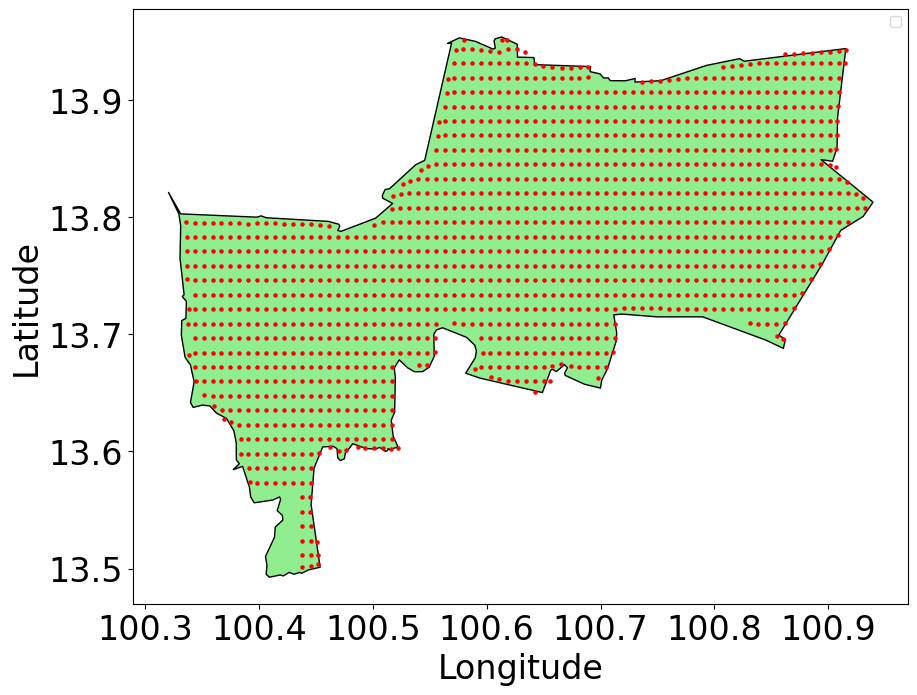

In [ ]:
from shapely.geometry import Point
import matplotlib.patheffects as pe
import geopandas as gpd

thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()

# Create geometry column in df
wind['geometry'] = [Point(xy) for xy in zip(wind['longitude'], wind['latitude'])]
gdf = gpd.GeoDataFrame(wind, geometry='geometry', crs='EPSG:4326')

thailand['centroid'] = thailand.geometry.centroid

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(10,10))
thailand.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['longitude', 'latitude'])

# for idx, row in thailand.iterrows():
#           ax.annotate(
#               text=row['NAME_1'],
#               xy=(row['centroid'].x, row['centroid'].y),
#               ha='center', va='center',
#               fontsize=20, color='black', weight='bold',
#               path_effects=[pe.withStroke(linewidth=2, foreground="white")]
#           )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Longitude', fontsize = 24)
plt.ylabel('Latitude', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

/tmp/ipython-input-3418058540.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  thailand['centroid'] = thailand.geometry.centroid
/tmp/ipython-input-3418058540.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


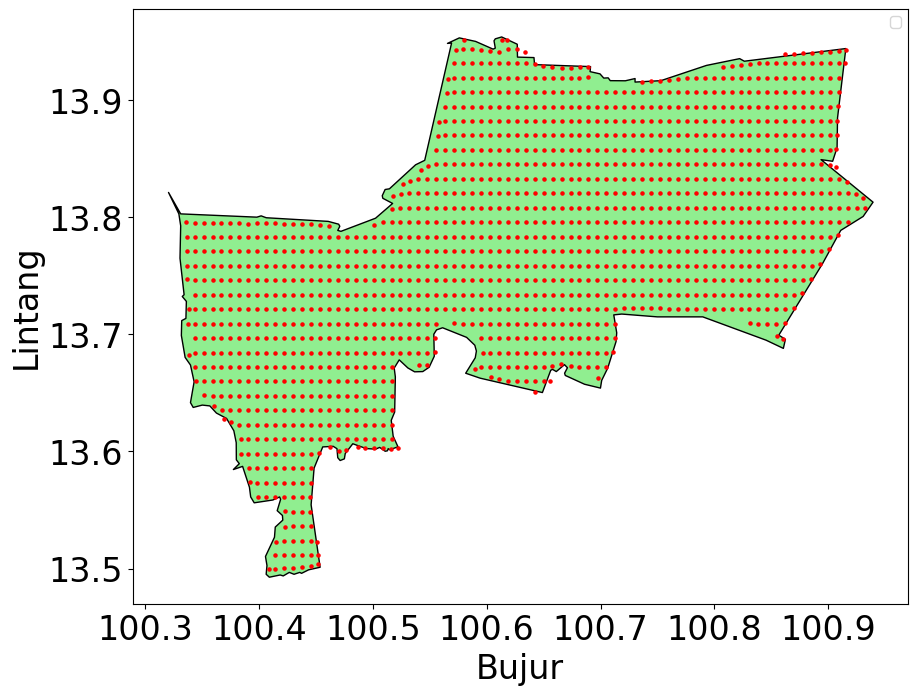

In [ ]:

thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()

# Create geometry column in df
df['geometry'] = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')

thailand['centroid'] = thailand.geometry.centroid

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(10,10))
thailand.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['longitude', 'latitude'])

# for idx, row in thailand.iterrows():
#           ax.annotate(
#               text=row['NAME_1'],
#               xy=(row['centroid'].x, row['centroid'].y),
#               ha='center', va='center',
#               fontsize=20, color='black', weight='bold',
#               path_effects=[pe.withStroke(linewidth=2, foreground="white")]
#           )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Bujur', fontsize = 24)
plt.ylabel('Lintang', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

In [ ]:
df['date'] = pd.to_datetime(df['date'])  #format date
start_date = datetime.datetime(2023, 5, 1) #pastikan tanggal mulainya benar
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"}) #rename kolom supaya sama antara df dan wind
wind=wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})

df.sort_values(by=['date','x_coord','y_coord'], inplace=True) #rapikan urutan tanggal, garis bujur, dan garis lintang

In [ ]:
wind

,date,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
1,2023-05-01,100.338063,13.682278,-0.755996,1.169993,1.392987,302.868698
3,2023-05-01,100.337941,13.708376,-0.755996,1.169993,1.392987,302.868698
4,2023-05-01,100.338148,13.721229,-0.755996,1.169993,1.392987,302.868698
6,2023-05-01,100.337116,13.747069,-0.803075,0.972524,1.261242,309.548640
7,2023-05-01,100.336273,13.758631,-0.803075,0.972524,1.261242,309.548640
...,...,...,...,...,...,...,...
1078932,2025-04-29,100.915276,13.942720,-0.804878,0.177327,0.824180,347.575309
1078934,2025-04-29,100.925230,13.807942,-0.815294,0.331706,0.880189,337.860854
1078935,2025-04-29,100.924874,13.819598,-0.815294,0.331706,0.880189,337.860854
1078938,2025-04-29,100.932461,13.807774,-0.815294,0.331706,0.880189,337.860854


In [ ]:
df=df.rename(columns={"mean":"NO2_mean"})

# Pembersihan Data
wind['date'] = pd.to_datetime(wind['date'])

#Gabungkan data polutan dengan data keceparan arah angin (sudah dikonversi jadi wx dan wy)
merged_df = pd.merge(df, wind, on=['x_coord', 'y_coord', 'date'], how='inner')

display(merged_df.head())

,date,NO2_mean,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
0,2023-05-01,0.000142,100.343405,13.721492,-0.714126,1.163645,1.365301,301.537324
1,2023-05-01,0.000142,100.343405,13.733842,-0.714126,1.163645,1.365301,301.537324
2,2023-05-01,0.000142,100.343405,13.709142,-0.714126,1.163645,1.365301,301.537324
3,2023-05-01,0.000151,100.343405,13.783242,-0.765924,0.952016,1.221874,308.817680
4,2023-05-01,0.000151,100.343405,13.746192,-0.765924,0.952016,1.221874,308.817680


In [ ]:
merged_df

,date,NO2_mean,x_coord,y_coord,geometry_x,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m,geometry_y
0,2023-05-01,0.000142,100.343405,13.721492,POINT (100.3434046188038 13.721491800671233),-0.714126,1.163645,1.365301,301.537324,POINT (100.3434046188038 13.721491800671233)
1,2023-05-01,0.000142,100.343405,13.733842,POINT (100.34340461881712 13.733841800630843),-0.714126,1.163645,1.365301,301.537324,POINT (100.34340461881712 13.733841800630843)
2,2023-05-01,0.000142,100.343405,13.709142,POINT (100.34340461881926 13.709141800702932),-0.714126,1.163645,1.365301,301.537324,POINT (100.34340461881926 13.709141800702932)
3,2023-05-01,0.000151,100.343405,13.783242,POINT (100.34340461882589 13.783241800550009),-0.765924,0.952016,1.221874,308.817680,POINT (100.34340461882589 13.783241800550009)
4,2023-05-01,0.000151,100.343405,13.746192,POINT (100.34340461883356 13.746191800629656),-0.765924,0.952016,1.221874,308.817680,POINT (100.34340461883356 13.746191800629656)
...,...,...,...,...,...,...,...,...,...,...
423565,2025-04-29,0.000089,100.909505,13.820292,POINT (100.90950461885528 13.820291800470915),-0.815294,0.331706,0.880189,337.860854,POINT (100.90950461885528 13.820291800470915)
423566,2025-04-29,0.000089,100.917098,13.796169,POINT (100.9170982346702 13.796168716028436),-0.815294,0.331706,0.880189,337.860854,POINT (100.9170982346702 13.796168716028436)
423567,2025-04-29,0.000089,100.917367,13.820292,POINT (100.91736711885083 13.82029180046748),-0.815294,0.331706,0.880189,337.860854,POINT (100.91736711885083 13.82029180046748)
423568,2025-04-29,0.000089,100.917367,13.807942,POINT (100.91736711885947 13.80794180050685),-0.815294,0.331706,0.880189,337.860854,POINT (100.91736711885947 13.80794180050685)


In [ ]:
merged_df.iloc[:,:-2].describe()

,date,NO2_mean,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,0.000120,100.613907,13.767418,0.283523,0.748113
min,2023-05-01 00:00:00,0.000009,100.343405,13.511542,-4.674856,-4.757746
25%,2023-10-31 00:00:00,0.000084,100.477067,13.709142,-0.628059,-0.591293
50%,2024-04-29 00:00:00,0.000105,100.595005,13.770892,0.166242,1.053226
75%,2024-10-29 00:00:00,0.000139,100.744392,13.820292,1.261403,1.978572
max,2025-04-29 00:00:00,0.000740,100.925230,13.943792,5.253960,6.101706
std,NaN,0.000058,0.171918,0.083353,1.382004,1.675972


/tmp/ipython-input-3892499013.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  thailand['centroid'] = thailand.geometry.centroid
/tmp/ipython-input-3892499013.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


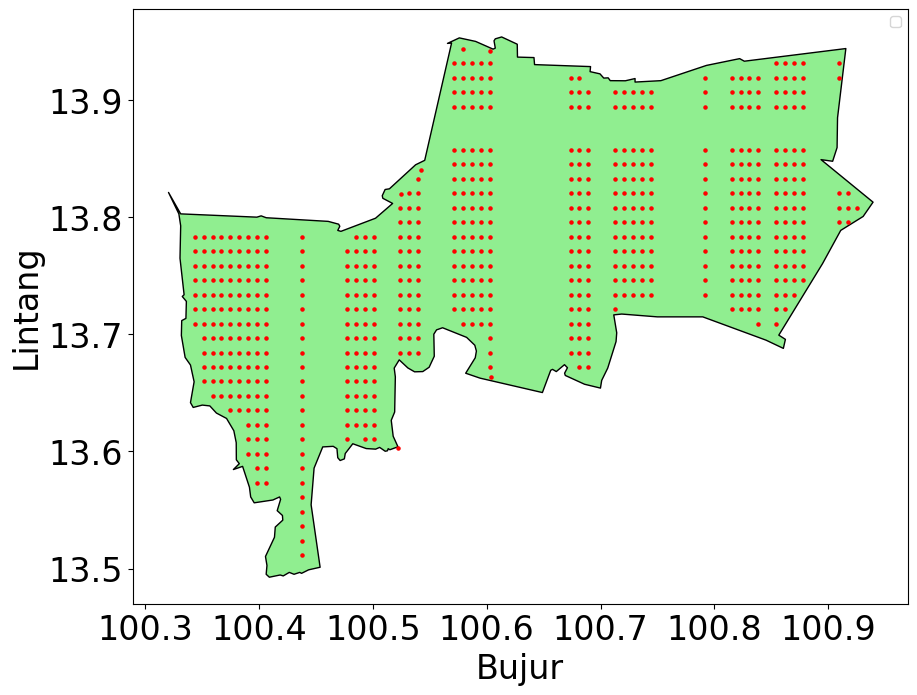

In [ ]:

thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()

# Create geometry column in df
merged_df['geometry'] = [Point(xy) for xy in zip(merged_df['x_coord'], merged_df['y_coord'])]
gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs='EPSG:4326')

thailand['centroid'] = thailand.geometry.centroid

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(10,10))
thailand.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['x_coord', 'y_coord'])

# for idx, row in thailand.iterrows():
#           ax.annotate(
#               text=row['NAME_1'],
#               xy=(row['centroid'].x, row['centroid'].y),
#               ha='center', va='center',
#               fontsize=20, color='black', weight='bold',
#               path_effects=[pe.withStroke(linewidth=2, foreground="white")]
#           )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Bujur', fontsize = 24)
plt.ylabel('Lintang', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

## Rata-rata Kecepatan Angin

In [ ]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

#Untuk setiap koordinat (x,y), rata-ratakan kecepatan angin wx dan wy sepanjang waktu
merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [ ]:
merged_df

,date,NO2_mean,u10,v10,x_coord,y_coord
0,2023-05-01,0.000142,0.348237,0.784429,100.343405,13.721492
1,2023-05-01,0.000142,0.348237,0.784429,100.343405,13.733842
2,2023-05-01,0.000142,0.348237,0.784429,100.343405,13.709142
3,2023-05-01,0.000151,0.303668,0.679754,100.343405,13.783242
4,2023-05-01,0.000151,0.303668,0.679754,100.343405,13.746192
...,...,...,...,...,...,...
423565,2025-04-29,0.000089,0.132474,0.638082,100.909505,13.820292
423566,2025-04-29,0.000089,0.132474,0.638082,100.917098,13.796169
423567,2025-04-29,0.000089,0.132474,0.638082,100.917367,13.820292
423568,2025-04-29,0.000089,0.132474,0.638082,100.917367,13.807942


In [ ]:
merged_df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,0.000120,0.283523,0.748113,100.613907,13.767418
min,2023-05-01 00:00:00,0.000009,0.047809,0.596048,100.343405,13.511542
25%,2023-10-31 00:00:00,0.000084,0.241943,0.679754,100.477067,13.709142
50%,2024-04-29 00:00:00,0.000105,0.292260,0.729230,100.595005,13.770892
75%,2024-10-29 00:00:00,0.000139,0.329148,0.784429,100.744392,13.820292
max,2025-04-29 00:00:00,0.000740,0.446781,1.127054,100.925230,13.943792
std,NaN,0.000058,0.064678,0.088489,0.171918,0.083353


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime, timedelta

df['time'] = (df['date'] - df['date'].min()).dt.days

start_date = datetime(2023, 5, 1)

target_day = 8
target_month = 1
target_year = 2025

target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

time_to_visualize = t

df_visualize = df[df['time'] == time_to_visualize].copy()
if df_visualize.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {df_visualize.shape}")
    display(df_visualize.head())

    thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
    thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()


In [ ]:
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

In [ ]:
merged_df.to_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_NO2.csv")

In [4]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_NO2.csv",index_col=0)

In [5]:
df['date'] = pd.to_datetime(df['date'])

## Teknik Rescaling

In [6]:
#Ubah dari tanggal ke dalam numerik
df['time'] = (df['date'] - df['date'].min()).dt.days

#Teknik Rescaling
scale = 1e-5
df.NO2_mean = df.NO2_mean/scale

df['x_coord'] = df['x_coord'] * 100
df['y_coord'] = df['y_coord'] * 100

In [ ]:
df


,date,NO2_mean,u10,v10,x_coord,y_coord,time
0,2023-05-01,14.160173,0.348237,0.784429,10034.340462,1372.149180,0
1,2023-05-01,14.160173,0.348237,0.784429,10034.340462,1373.384180,0
2,2023-05-01,14.160173,0.348237,0.784429,10034.340462,1370.914180,0
3,2023-05-01,15.088663,0.303668,0.679754,10034.340462,1378.324180,0
4,2023-05-01,15.088663,0.303668,0.679754,10034.340462,1374.619180,0
...,...,...,...,...,...,...,...
423565,2025-04-29,8.945238,0.132474,0.638082,10090.950462,1382.029180,729
423566,2025-04-29,8.945238,0.132474,0.638082,10091.709823,1379.616872,729
423567,2025-04-29,8.945238,0.132474,0.638082,10091.736712,1382.029180,729
423568,2025-04-29,8.945238,0.132474,0.638082,10091.736712,1380.794180,729


In [ ]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,12.020415,0.283523,0.748113,10061.390695,1376.741780,364.882515
min,2023-05-01 00:00:00,0.870819,0.047809,0.596048,10034.340462,1351.154180,0.000000
25%,2023-10-31 00:00:00,8.366587,0.241943,0.679754,10047.706712,1370.914180,183.000000
50%,2024-04-29 00:00:00,10.505674,0.292260,0.729230,10059.500462,1377.089180,364.000000
75%,2024-10-29 00:00:00,13.892418,0.329148,0.784429,10074.439212,1382.029180,547.000000
max,2025-04-29 00:00:00,73.968811,0.446781,1.127054,10092.522962,1394.379180,729.000000
std,NaN,5.797119,0.064678,0.088489,17.191771,8.335325,210.488126


## Lowpass Filtering dan Cek Normalitas Residu

In [ ]:
def low_pass_filter(series, cutoff=0.45):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real



full_dates = pd.date_range(start=df['date'].min(),end=df['date'].max(),freq='D')
coords = df[['x_coord', 'y_coord']].drop_duplicates()
full_index = pd.MultiIndex.from_frame(
    coords.merge(pd.DataFrame({'date': full_dates}), how='cross')
)

df2 = (
    df.set_index(['x_coord', 'y_coord', 'date'])
    .reindex(full_index)
    .reset_index()
    .rename(columns={'level_0': 'x_coord', 'level_1': 'y_coord', 'level_2': 'date'})
)

df2['NO2_mean'] = (df2.groupby(['x_coord', 'y_coord'])['NO2_mean'].transform(lambda s: s.interpolate(method='linear', limit_direction='both')))
df['NO2_filtered'] = df.groupby(['x_coord', 'y_coord'])['NO2_mean'].transform(low_pass_filter)
df = df[['date', 'NO2_mean','u10','v10','x_coord', 'y_coord','time']].merge(
    df[['date', 'x_coord', 'y_coord', 'NO2_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)

# 'df' now contains the new 'NO2_filtered' column with the results.
print(df.head())

        date   NO2_mean       u10       v10       x_coord     y_coord  time  \
0 2023-05-01  14.160173  0.348237  0.784429  10034.340462  1372.14918     0   
1 2023-05-01  14.160173  0.348237  0.784429  10034.340462  1373.38418     0   
2 2023-05-01  14.160173  0.348237  0.784429  10034.340462  1370.91418     0   
3 2023-05-01  15.088663  0.303668  0.679754  10034.340462  1378.32418     0   
4 2023-05-01  15.088663  0.303668  0.679754  10034.340462  1374.61918     0   

   NO2_filtered  
0     14.088170  
1     14.088170  
2     14.088170  
3     14.238412  
4     14.238412  


In [ ]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,12.020415,0.283523,0.748113,10061.390695,1376.741780,364.882515,12.020415
min,2023-05-01 00:00:00,0.870819,0.047809,0.596048,10034.340462,1351.154180,0.000000,1.558087
25%,2023-10-31 00:00:00,8.366587,0.241943,0.679754,10047.706712,1370.914180,183.000000,8.339682
50%,2024-04-29 00:00:00,10.505674,0.292260,0.729230,10059.500462,1377.089180,364.000000,10.556475
75%,2024-10-29 00:00:00,13.892418,0.329148,0.784429,10074.439212,1382.029180,547.000000,13.973814
max,2025-04-29 00:00:00,73.968811,0.446781,1.127054,10092.522962,1394.379180,729.000000,67.505884
std,NaN,5.797119,0.064678,0.088489,17.191771,8.335325,210.488126,5.680008


In [8]:
from scipy.stats import kstest
import pandas as pd

# Assume 'filtered_df' is your DataFrame with NO2_mean and NO2_filtered columns

def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['NO2_mean'] - group['NO2_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord     y_coord  Test Statistic (KS)  P-value (KS) Normality (KS)  \
0  10034.340462  1372.14918             0.138184  2.961547e-12   Not Gaussian   
1  10034.340462  1373.38418             0.138184  2.961547e-12   Not Gaussian   
2  10034.340462  1370.91418             0.138184  2.961547e-12   Not Gaussian   
3  10034.340462  1378.32418             0.102713  5.767209e-07   Not Gaussian   
4  10034.340462  1374.61918             0.102713  5.767209e-07   Not Gaussian   

   Data Points  
0          708  
1          708  
2          708  
3          709  
4          709  


/tmp/ipython-input-1439980828.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [ ]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,395
Not Gaussian,202


In [ ]:
# Select up to 20 unique locations randomly
non_gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Not Gaussian'][['x_coord', 'y_coord']]

selected_locations = non_gaussian_locations.sample(min(20, len(non_gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = df[(df['x_coord'] == x_c) & (df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['NO2_mean'] - location_data['NO2_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Konsentrasi NO2, Filtering, dan Residu di titik ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=14)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['NO2_mean'], label='Data Asli', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['NO2_filtered'], label='Data Hasil Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residu', color='gray', alpha=0.6)

    plt.xlabel("Waktu (t)")
    plt.ylabel("Konsentrasi NO2 dalam 10^-5 mol/m^2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Distribusi Residu Filtering di titik ({x_c/100:.2f}, {y_c/100:.2f})')
    plt.xlabel("Residu")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [9]:
# Select up to 20 unique locations randomly
non_gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Not Gaussian'][['x_coord', 'y_coord']]

selected_locations = non_gaussian_locations.sample(min(20, len(non_gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = df[(df['x_coord'] == x_c) & (df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['NO2_mean'] - location_data['NO2_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Before and After Low-Pass Filtering, along with Residuals ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=18)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['NO2_mean'], label='Data Before Low-pass Filtering', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['NO2_filtered'], label='Data After Low-pass Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residuals', color='gray', alpha=0.6)

    plt.xlabel("Time (t)", fontsize=18)
    plt.ylabel(r"$\mathrm{NO_2} \; (10^{-5} \,\mathrm{mol/m^2})$", fontsize=18)
    plt.tick_params(axis="both", which='major', labelsize=18)
    plt.legend(fontsize=16, loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Residual of Low-pass Filtering at Coordinate ({x_c/100:.2f}, {y_c/100:.2f})',fontsize=16)
    plt.tick_params(axis="both", which='major', labelsize=16)
    plt.xlabel("Residual", fontsize=20)
    plt.ylabel("Frequency", fontsize=20)
    plt.legend(fontsize=16, loc='upper right')
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Select up to 20 unique locations randomly
gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Gaussian'][['x_coord', 'y_coord']]

selected_locations = gaussian_locations.sample(min(20, len(gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = df[(df['x_coord'] == x_c) & (df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['NO2_mean'] - location_data['NO2_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Konsentrasi NO2, Filtering, dan Residu di titik ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=14)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['NO2_mean'], label='Data Asli', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['NO2_filtered'], label='Data Hasil Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residu', color='gray', alpha=0.6)

    plt.xlabel("Waktu (t)")
    plt.ylabel("Konsentrasi NO2 dalam 10^-5 mol/m^2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Distribusi Residu Filtering di titik ({x_c/100:.2f}, {y_c/100:.2f})')
    plt.xlabel("Residu")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [10]:
# Select up to 20 unique locations randomly
gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Gaussian'][['x_coord', 'y_coord']]

selected_locations = gaussian_locations.sample(min(20, len(gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = df[(df['x_coord'] == x_c) & (df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['NO2_mean'] - location_data['NO2_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Before and After Low-Pass Filtering, along with Residuals ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=18)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['NO2_mean'], label='Data Before Low-pass Filtering', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['NO2_filtered'], label='Data After Low-pass Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residuals', color='gray', alpha=0.6)

    plt.xlabel("Time (t)", fontsize=18)
    plt.ylabel(r"$\mathrm{NO_2} \; (10^{-5} \,\mathrm{mol/m^2})$", fontsize=18)
    plt.tick_params(axis="both", which='major', labelsize=18)
    plt.legend(fontsize=16, loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Residual of Low-pass Filtering at Coordinate ({x_c/100:.2f}, {y_c/100:.2f})',fontsize=16)
    plt.tick_params(axis="both", which='major', labelsize=16)
    plt.xlabel("Residual", fontsize=20)
    plt.ylabel("Frequency", fontsize=20)
    plt.legend(fontsize=16, loc='upper right')
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,12.020415,0.283523,0.748113,10061.390695,1376.741780,364.882515,12.020415
min,2023-05-01 00:00:00,0.870819,0.047809,0.596048,10034.340462,1351.154180,0.000000,1.558087
25%,2023-10-31 00:00:00,8.366587,0.241943,0.679754,10047.706712,1370.914180,183.000000,8.339682
50%,2024-04-29 00:00:00,10.505674,0.292260,0.729230,10059.500462,1377.089180,364.000000,10.556475
75%,2024-10-29 00:00:00,13.892418,0.329148,0.784429,10074.439212,1382.029180,547.000000,13.973814
max,2025-04-29 00:00:00,73.968811,0.446781,1.127054,10092.522962,1394.379180,729.000000,67.505884
std,NaN,5.797119,0.064678,0.088489,17.191771,8.335325,210.488126,5.680008


In [ ]:
averaged_df = df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
0,2023-05-01,14.160173,10034.340462,1372.149180,0,14.088170,0.348237,0.784429
1,2023-05-01,14.160173,10034.340462,1373.384180,0,14.088170,0.348237,0.784429
2,2023-05-01,14.160173,10034.340462,1370.914180,0,14.088170,0.348237,0.784429
3,2023-05-01,15.088663,10034.340462,1378.324180,0,14.238412,0.303668,0.679754
4,2023-05-01,15.088663,10034.340462,1374.619180,0,14.238412,0.303668,0.679754
...,...,...,...,...,...,...,...,...
423565,2025-04-29,8.945238,10090.950462,1382.029180,729,9.265307,0.132474,0.638082
423566,2025-04-29,8.945238,10091.709823,1379.616872,729,9.265307,0.132474,0.638082
423567,2025-04-29,8.945238,10091.736712,1382.029180,729,9.265307,0.132474,0.638082
423568,2025-04-29,8.945238,10091.736712,1380.794180,729,9.265307,0.132474,0.638082


In [ ]:
filtered_df.describe()

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
count,423570,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000,423570.000000
mean,2024-04-29 21:10:49.320773632,12.020415,10061.390695,1376.741780,364.882515,12.020415,0.283523,0.748113
min,2023-05-01 00:00:00,0.870819,10034.340462,1351.154180,0.000000,1.558087,0.047809,0.596048
25%,2023-10-31 00:00:00,8.366587,10047.706712,1370.914180,183.000000,8.339682,0.241943,0.679754
50%,2024-04-29 00:00:00,10.505674,10059.500462,1377.089180,364.000000,10.556475,0.292260,0.729230
75%,2024-10-29 00:00:00,13.892418,10074.439212,1382.029180,547.000000,13.973814,0.329148,0.784429
max,2025-04-29 00:00:00,73.968811,10092.522962,1394.379180,729.000000,67.505884,0.446781,1.127054
std,NaN,5.797119,17.191771,8.335325,210.488126,5.680008,0.064678,0.088489


# Split Train Testing

In [ ]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(296499, 3), dtype=float32, numpy=
array([[  594.    , 10087.806 ,  1383.2642],
       [  196.    , 10052.424 ,  1375.8541],
       [  695.    , 10068.936 ,  1378.3242],
       ...,
       [   66.    , 10087.02  ,  1391.9092],
       [  307.    , 10081.516 ,  1389.4392],
       [  319.    , 10060.287 ,  1391.9092]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(127071, 3), dtype=float32, numpy=
array([[  437.    , 10037.485 ,  1369.6792],
       [   95.    , 10068.936 ,  1379.5592],
       [  179.    , 10072.08  ,  1383.2642],
       ...,
       [  228.    , 10067.363 ,  1372.1492],
       [  254.    , 10067.363 ,  1369.6792],
       [  211.    , 10083.874 ,  1390.6742]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(296499, 1), dtype=float32, numpy=
array([[ 9.155551 ],
       [ 5.6641955],
       [ 9.98596  ],
       ...,
       [11.616995 ],
       [ 7.880227 ],
       [14.885566 ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(127071, 1), dtype=float32, numpy=
array([[ 6.6868205],
       [ 8.387415 ],
       [10.5220995],
       ...,
       [14.790911 ],
       [23.52237  ],
       [ 7.0822496]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(296499, 1), dtype=float32, numpy=
array([[0.19223039],
       [0.2922604 ],
       [0.27202746],
       ...,
       [0.17678893],
       [0.17678893],
       [0.25660715]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(296499, 1), dtype=float32, numpy=
array([[0.6816191 ],
       [0.72923046],
       [0.7406938 ],
       ...,
       [0.64210343],
       [0.64210343],
       [0.64908916]], dtype=float32)>

# Persiapan PINN

## Persiapan Arsitektur PINN

In [ ]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
ub-lb

array([729.        ,  58.18250001,  43.22499991])

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':140,'activation':'swish', 'trainable_B':True, 'sigmas':[3,5], 'mapping_size':64}
n_models = 20

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

## Persiapan Automatic Differentiation dan Fungsi Loss

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model, u_data, Wu=Wu, Wv=Wv) # Pass u_data, Wu, Wv

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train, Wu=W_u, Wv=W_v): # Added Wu, Wv here
    # tf.print(tf.reduce_mean(u_x))
    # tf.print(tf.reduce_mean(u_y))
    # tf.print(tf.reduce_mean(u_xx))
    # tf.print(tf.reduce_mean(u_yy))
    pde_residual = scale*(u_t) +scale* W_u * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)
    loss = tf.reduce_mean(tf.square(pde_residual))
    return loss

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))
    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv) # Pass Wu and Wv here

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10,  Wu=W_u, Wv=W_v): # Added Wu and Wv here
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- lambd * (scale*u_xx + scale*u_yy)
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Pelatihan Invers

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8, N_fwd=None)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

Streaming output truncated to the last 5000 lines.
Iteration 189, Loss: 18.57937240600586
Iteration 190, Loss: 19.07462501525879
Iteration 191, Loss: 19.70472526550293
Iteration 192, Loss: 17.58102798461914
Iteration 193, Loss: 19.08864402770996
Iteration 194, Loss: 20.190792083740234
Iteration 195, Loss: 18.157930374145508
Iteration 196, Loss: 20.74702262878418
Iteration 197, Loss: 18.37868309020996
Iteration 198, Loss: 19.33690071105957
Iteration 199, Loss: 17.81891632080078
Iteration 200, Loss: 19.329532623291016
Iteration 201, Loss: 17.914077758789062
Iteration 202, Loss: 18.891504287719727
Iteration 203, Loss: 17.69774627685547
Iteration 204, Loss: 18.726390838623047
Iteration 205, Loss: 17.681257247924805
Iteration 206, Loss: 18.27101707458496
Iteration 207, Loss: 17.881914138793945
Iteration 208, Loss: 17.8538818359375
Iteration 209, Loss: 17.939329147338867
Iteration 210, Loss: 17.664508819580078
Iteration 211, Loss: 17.924705505371094
Iteration 212, Loss: 17.5584716796875
Iter

In [ ]:
path = dir + "NO2Model/Fourier/Softplus_Bangkok_Fourier_inv_swish/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models
initial_lambdas = [0.5]
for i in range(60):
    hists_Adam1[i] = []
    lambd_Adam1[i]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

## Grafik Loss

<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-4233014439.py:18: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-4233014439.py:18: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-4233014439.py:18: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']


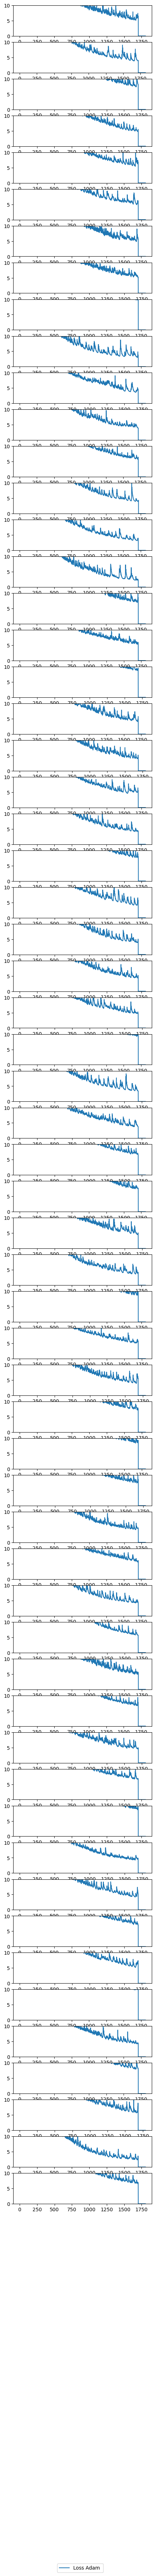

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(5,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,10])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,5])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,5])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,5])

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.335169
Attempt 2,0.301228
Attempt 3,0.360793
Attempt 4,0.367777
Attempt 5,0.449291
Attempt 6,0.489703
Attempt 7,0.411903
Attempt 8,0.429273
Attempt 9,0.410511
Attempt 10,0.419038


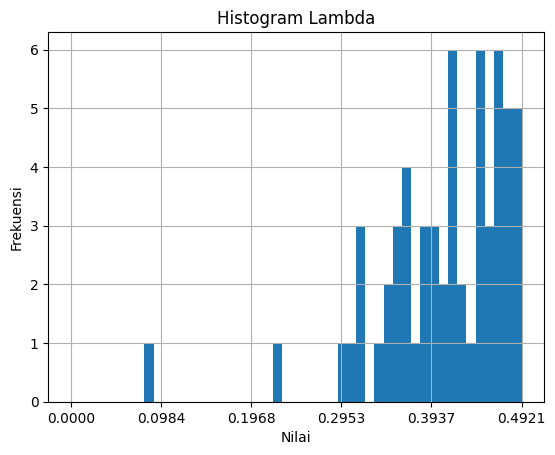

In [ ]:
bins = np.linspace(1e-5,max(df.Adam),50)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=bins, align='mid')

plt.xticks(np.linspace(1e-5, max(df.Adam), 6))  # Misal xtick tiap 0.00001
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.title("Histogram Lambda")
plt.grid(True)
plt.show()

In [ ]:
df.describe()

,Adam
count,60.000000
mean,0.407666
std,0.072100
min,0.087321
25%,0.367052
50%,0.419611
75%,0.463452
max,0.492089


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[0]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=15, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

params = stats.burr.fit(data)
mean = stats.burr.mean(*params)
print("Mean:", mean)

# Pelatihan Kasus Forward

In [ ]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':140,'activation':'swish', 'trainable_B':True, 'sigmas':[3.0,5.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

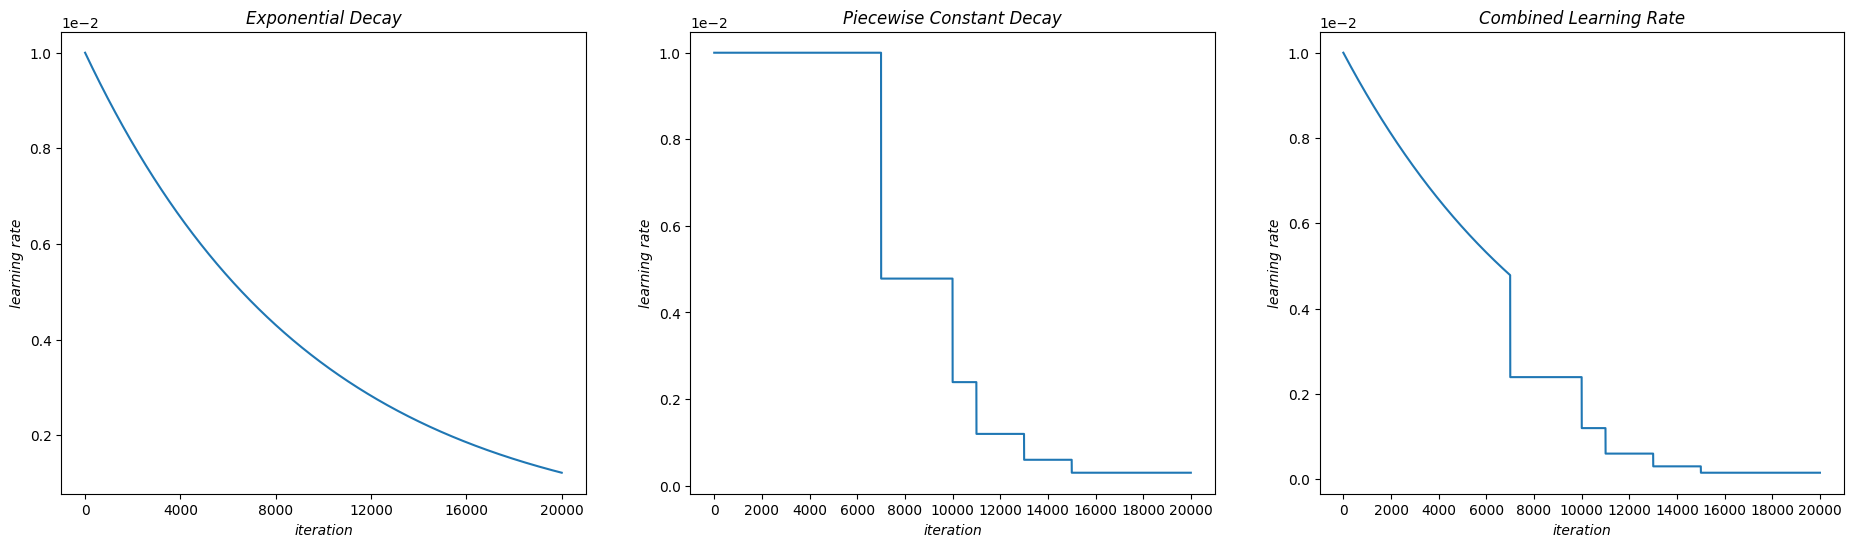

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [ ]:
# pred_lambda = [0.4029674879840506]
pred_lambda = [0.4064684461112839]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout, batch_size = 4096)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 1.01328157e-09 Data Loss: 8.41397095 Total Loss: 84.1397095
PDE Loss: 6.71639355e-10 Data Loss: 8.47785187 Total Loss: 84.7785187
PDE Loss: 1.15722698e-09 Data Loss: 8.00735092 Total Loss: 80.0735092
PDE Loss: 6.06950601e-10 Data Loss: 8.20333862 Total Loss: 82.0333862
PDE Loss: 9.09049946e-10 Data Loss: 7.87586594 Total Loss: 78.7586594
PDE Loss: 8.593663e-10 Data Loss: 8.40109253 Total Loss: 84.0109253
PDE Loss: 7.12153392e-10 Data Loss: 8.88267136 Total Loss: 88.8267136
PDE Loss: 9.75327374e-10 Data Loss: 8.32728481 Total Loss: 83.27285
PDE Loss: 7.74366737e-10 Data Loss: 8.52876759 Total Loss: 85.287674
PDE Loss: 7.61962715e-10 Data Loss: 8.77381611 Total Loss: 87.7381592
PDE Loss: 9.87159465e-10 Data Loss: 8.27263451 Total Loss: 82.7263489
PDE Loss: 7.17062743e-10 Data Loss: 7.55664492 Total Loss: 75.566452
PDE Loss: 7.9559942e-10 Data Loss: 7.62597418 Total Loss: 76.2597427
PDE Loss: 8.09869838e-10 Data Loss: 7.793859 T

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 5.1220439e-10 Data Loss: 9.72367477 Total Loss: 97.2367477
PDE Loss: 5.02795805e-10 Data Loss: 8.22848606 Total Loss: 82.2848587
PDE Loss: 6.60385635e-10 Data Loss: 9.84923172 Total Loss: 98.4923172
PDE Loss: 6.14889306e-10 Data Loss: 9.69685364 Total Loss: 96.9685364
PDE Loss: 7.01426695e-10 Data Loss: 8.72788429 Total Loss: 87.2788391
PDE Loss: 5.94244098e-10 Data Loss: 10.1821728 Total Loss: 101.821732
PDE Loss: 6.68232081e-10 Data Loss: 10.0463371 Total Loss: 100.463371
PDE Loss: 5.90818228e-10 Data Loss: 10.3321838 Total Loss: 103.321838
PDE Loss: 5.61150959e-10 Data Loss: 9.24103355 Total Loss: 92.4103394
PDE Loss: 6.95858926e-10 Data Loss: 9.39523506 Total Loss: 93.9523468
PDE Loss: 6.543453e-10 Data Loss: 9.61499691 Total Loss: 96.149971
PDE Loss: 6.62748412e-10 Data Loss: 9.70722389 Total Loss: 97.0722351
PDE Loss: 1.36972667e-09 Data Loss: 10.2176867 Total Loss: 102.176865
PDE Loss: 8.64441796e-10 Data Loss: 8.95354

In [ ]:
path = dir + "NO2Model/Fourier/Softplus_Bangkok_Fourier_fwd_swish/"

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [ ]:
n_models = 5

models_Adam_comb = [None] * n_models

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':140,'activation':'swish', 'trainable_B':True, 'sigmas':[3.0,5.0], 'mapping_size':64}


for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )

hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

## Grafik Loss

len Atempt-0 Lambda ke- 0:  122
\\
len Atempt-1 Lambda ke- 0:  122
\\
len Atempt-2 Lambda ke- 0:  117
\\
len Atempt-3 Lambda ke- 0:  117
\\
len Atempt-4 Lambda ke- 0:  119
\\


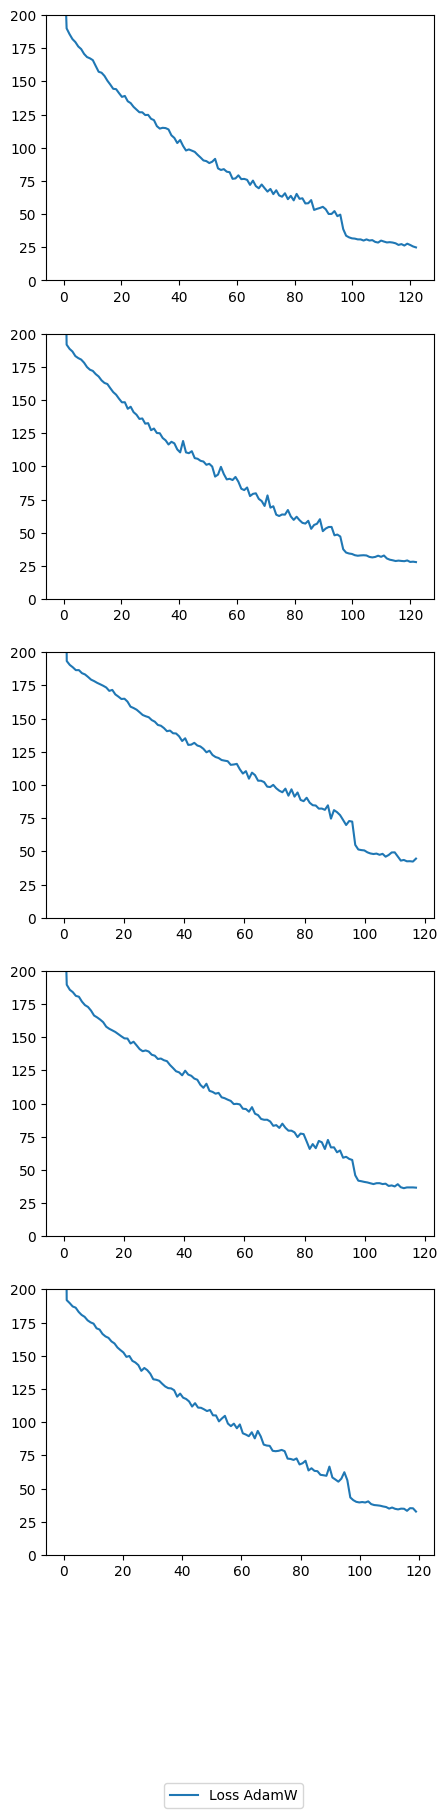

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,2e2])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.0477445, 9.795573)"
Attempt 2,"(1.1842395, 11.09967)"
Attempt 3,"(1.4222912, 13.064973)"
Attempt 4,"(1.2224523, 11.017318)"
Attempt 5,"(1.2236779, 11.215453)"


In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.1694921, 10.832941)"
Attempt 2,"(1.2618855, 11.78179)"
Attempt 3,"(1.515165, 13.893875)"
Attempt 4,"(1.3281634, 11.923127)"
Attempt 5,"(1.3020488, 11.867454)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  1.315351  0.126886  0.096465  12.059837  1.118255  0.092726


In [ ]:
weights = models_Adam_comb[0][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-1.8934901e+00 -7.5825930e-01 -6.4924634e-01 -4.9925403e-04
   6.8735676e+00  2.9749937e+00 -3.6737721e+00 -1.0839939e+00
   7.1773634e+00 -3.8933292e-02  1.5881169e+00  5.2239079e+00
  -3.4429532e-01  6.9902167e+00  9.8693296e-02  2.4342287e-01
   3.3289981e-01 -1.6852121e+00 -2.0881181e+00  3.8533130e+00
  -2.4777067e+00  1.4119499e+00 -2.0709035e+00 -4.1841302e-04
   3.4511395e+00 -3.4603469e+00  3.4683020e-04 -5.5386347e-01
  -5.2117529e+00 -2.6521804e+00  4.5424814e+00  2.6026208e+00
  -4.5596213e+00  5.2057800e+00 -3.6307335e-01  4.3077173e+00
  -2.7464395e+00 -1.3200563e-01  8.6250764e-01  3.5820389e+00
  -2.7812696e+00  1.2751310e-01 -1.3434259e+00  8.9392918e-01
   1.0128540e+00  9.3683851e-01 -4.7336068e+00  3.1606615e+00
  -2.7731895e+00 -4.8385735e+00 -4.1068152e-01 -1.6995449e+00
  -9.9666733e-01 -1.9428707e+00  1.4280682e+00  3.6241879e+00
  -2.7400467e+00  3.8368306e+00 -5.2384537e-01 -2.8323240e-04
   7.4552733e-01  5.1386986e+00 -2.5298543e+

# Rekonstruksi atau Imputasi

## Imputasi

In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/NO2_Land_Grid_Bangkok.csv")
df['date'] = pd.to_datetime(df['date'])
df=df.rename(columns={"mean":"NO2_mean","latitude":"y_coord","longitude":"x_coord"})
df['time'] = (df['date'] - df['date'].min()).dt.days
df_2 = df[df["NO2_mean"] > 0]

df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

In [ ]:
print(len(df))

1078940


In [ ]:
missing_rows = df[(df["NO2_mean"].isna()) | (df["NO2_mean"] < 0)][["time", "x_coord", "y_coord"]]
print(len(missing_rows))

# --- Convert to numpy for model input ---
X_missing = missing_rows.to_numpy(dtype=np.float32)

# --- Predict using your model ---
y_pred = models_Adam_comb[0][0].predict_on_batch(X_missing).reshape(-1)
y_pred = y_pred*1e-5
df.x_coord = df.x_coord/100
df.y_coord = df.y_coord/100
df_imputation = df.copy()

# --- Fill missing values ---
df_imputation.loc[(df_imputation["NO2_mean"].isna()) | (df_imputation["NO2_mean"] < 0), "NO2_mean"] = y_pred

df_imputation.describe()

90431


,date,NO2_mean,x_coord,y_coord,time
count,1078940,1.078940e+06,1.078940e+06,1.078940e+06,1.078940e+06
mean,2024-04-29 11:59:59.999999488,1.180489e-04,1.006277e+02,1.376989e+01,3.645000e+02
min,2023-05-01 00:00:00,8.212270e-11,1.003361e+02,1.349963e+01,0.000000e+00
25%,2023-10-30 00:00:00,8.309842e-05,1.004849e+02,1.370914e+01,1.820000e+02
50%,2024-04-29 12:00:00,1.042976e-04,1.006265e+02,1.377089e+01,3.645000e+02
75%,2024-10-29 00:00:00,1.360121e-04,1.007680e+02,1.384499e+01,5.470000e+02
max,2025-04-29 00:00:00,7.396881e-04,1.009325e+02,1.395146e+01,7.290000e+02
std,NaN,5.547026e-05,1.635927e-01,9.704283e-02,2.107327e+02


In [ ]:
missing_rows.time.value_counts()[-720:]

,count
time,
564,1067
383,1013
180,912
719,812
711,812
...,...
262,85
263,85
264,85


In [ ]:
df_imputation

,date,NO2_mean,x_coord,y_coord,time
0,2023-05-01,0.000114,100.338864,13.676988,0
1,2023-05-01,0.000144,100.338063,13.682278,0
2,2023-05-01,0.000116,100.338612,13.701442,0
3,2023-05-01,0.000144,100.337941,13.708376,0
4,2023-05-01,0.000144,100.338148,13.721229,0
...,...,...,...,...,...
1078935,2025-04-29,0.000089,100.924874,13.819598,729
1078936,2025-04-29,0.000103,100.922257,13.827371,729
1078937,2025-04-29,0.000101,100.930979,13.800684,729
1078938,2025-04-29,0.000089,100.932461,13.807774,729


In [ ]:
#FILTERED DATA
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

unique_coords = df[['time','x_coord', 'y_coord']].drop_duplicates()

df.x_coord = df.x_coord/100
df.y_coord = df.y_coord/100

# Merge with the filtered_df to check presence of NO2_filtered
merged = unique_coords.merge(filtered_df[['time', 'x_coord', 'y_coord', 'NO2_filtered']],
                          on=['time', 'x_coord', 'y_coord'],
                          how='left')

# Select only the rows where NO2_filtered is missing
missing_rows = merged[merged['NO2_filtered'].isna()].drop(columns='NO2_filtered')

# Result: only (time, x_coord, y_coord) with missing NO2_filtered
missing_rows

# --- Predict using your model ---
X_missing_filtered = missing_rows[['time', 'x_coord', 'y_coord']].values
y_pred = models_Adam_comb[0][0].predict_on_batch(X_missing_filtered).reshape(-1)

df_filtered_imputation = filtered_df[["time","x_coord","y_coord","NO2_filtered"]]
missing_rows['NO2_filtered'] = y_pred

# Merge predicted values back into original dataframe
df_filtered_imputation = pd.concat([df_filtered_imputation, missing_rows],axis=0)

df_filtered_imputation.describe()

df_filtered_imputation.to_csv("Imputation_FilteredData_NO2_Bangkok_M3_Swish+Softplus.csv")

In [ ]:
df_filtered_imputation.x_coord = df_filtered_imputation.x_coord/100
df_filtered_imputation.y_coord = df_filtered_imputation.y_coord/100
df_filtered_imputation.NO2_filtered = df_filtered_imputation.NO2_filtered*scale

df_filter = filtered_df.copy()
df_filter.x_coord = df_filter.x_coord/100
df_filter.y_coord = df_filter.y_coord/100
df_filter.NO2_filtered = df_filter.NO2_filtered*scale

df_filtered_imputation = df_filtered_imputation.sort_values(
    by=['time', 'x_coord', 'y_coord']
).reset_index(drop=True)

## Rekonstruksi

In [ ]:
import numpy as np
import pandas as pd
import math
import os
from google.colab import files
from concurrent.futures import ThreadPoolExecutor

# --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# Misal Anda sudah memiliki filtered_df
# Jika belum, upload:
# uploaded = files.upload()
# filtered_df = pd.read_csv("filtered_df.csv")

step = 0.5  # Resolusi

t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


# --- 2. Pilih model dan path hasil ---
target_indices = [(0, 0)]  # sesuaikan
models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
model_labels   = [f"m{i}_{j}" for i, j in target_indices]
file_paths     = [f"/content/Penalty_Softplus_NO2_Bangkok_M3_swish_prediction_{label}.csv" for label in model_labels]

# --- 3. Buat file output kosong dengan header ---
for path in file_paths:
    if os.path.exists(path):
        os.remove(path)
    with open(path, "w") as f:
        f.write("t,x,y,prediction\n")

# --- 4. Precompute spatial meshgrid (xy pairs) sekali saja ---
xy_pairs = np.stack(np.meshgrid(x_points, y_points, indexing="ij"), -1).reshape(-1, 2)

# --- 5. Fungsi batch generator ---
def gen_batches(t_vec, batch_size=1_000_000):
    for t in t_vec:
        t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
        tx_y = np.hstack([t_col, xy_pairs])
        n_rows = tx_y.shape[0]
        n_batch = math.ceil(n_rows / batch_size)
        for k in range(n_batch):
            yield t, tx_y[k * batch_size : (k + 1) * batch_size]

# --- 6. Fungsi prediksi + tulis ke file ---
def predict_and_write(model, batch, path):
    pred = model.predict_on_batch(batch).reshape(-1, 1)
    output = np.hstack([batch, pred])
    df = pd.DataFrame(output, columns=["t", "x", "y", "prediction"])
    df.to_csv(path, mode="a", header=False, index=False, float_format="%.6g")

# --- 7. Loop utama: batch per waktu + paralel tulis model ---
for t_val, batch in gen_batches(t_points):
    print(f"Processing time: {t_val}, Batch shape: {batch.shape}")
    with ThreadPoolExecutor() as executor:
        for model, path in zip(models_to_use, file_paths):
            executor.submit(predict_and_write, model, batch, path)

Processing time: 0.0, Batch shape: (10384, 3)
Processing time: 1.0, Batch shape: (10384, 3)
Processing time: 2.0, Batch shape: (10384, 3)
Processing time: 3.0, Batch shape: (10384, 3)
Processing time: 4.0, Batch shape: (10384, 3)
Processing time: 5.0, Batch shape: (10384, 3)
Processing time: 6.0, Batch shape: (10384, 3)
Processing time: 7.0, Batch shape: (10384, 3)
Processing time: 8.0, Batch shape: (10384, 3)
Processing time: 9.0, Batch shape: (10384, 3)
Processing time: 10.0, Batch shape: (10384, 3)
Processing time: 11.0, Batch shape: (10384, 3)
Processing time: 12.0, Batch shape: (10384, 3)
Processing time: 13.0, Batch shape: (10384, 3)
Processing time: 14.0, Batch shape: (10384, 3)
Processing time: 15.0, Batch shape: (10384, 3)
Processing time: 16.0, Batch shape: (10384, 3)
Processing time: 17.0, Batch shape: (10384, 3)
Processing time: 18.0, Batch shape: (10384, 3)
Processing time: 19.0, Batch shape: (10384, 3)
Processing time: 20.0, Batch shape: (10384, 3)
Processing time: 21.0, 

In [ ]:
prediction_df =pd.read_csv("/content/Penalty_Softplus_NO2_Bangkok_M3_swish_prediction_m0_0.csv")
prediction_cleaned_df =prediction_df.copy()
prediction_cleaned_df['prediction'] = prediction_df['prediction'].apply(lambda x: 0 if x < 0 else x)

prediction_df.prediction = prediction_df.prediction*1e-5
prediction_df.x = prediction_df.x/100
prediction_df.y = prediction_df.y/100

In [ ]:
prediction_df.describe()

,t,x,y,prediction
count,7.580320e+06,7.580320e+06,7.580320e+06,7.580320e+06
mean,3.645000e+02,1.006355e+02,1.372900e+01,1.218177e-04
std,2.107327e+02,1.703122e-01,1.270089e-01,5.053035e-05
min,0.000000e+00,1.003430e+02,1.351150e+01,0.000000e+00
25%,1.820000e+02,1.004880e+02,1.362025e+01,8.856450e-05
50%,3.645000e+02,1.006355e+02,1.372900e+01,1.111290e-04
75%,5.470000e+02,1.007830e+02,1.383775e+01,1.411490e-04
max,7.290000e+02,1.009280e+02,1.394650e+01,6.851180e-04


In [ ]:
len(prediction_df[prediction_df.prediction<0])

0

In [ ]:
prediction_df

,t,x,y,prediction
0,0,100.343,13.5115,0.000078
1,0,100.343,13.5165,0.000081
2,0,100.343,13.5215,0.000088
3,0,100.343,13.5265,0.000097
4,0,100.343,13.5315,0.000101
...,...,...,...,...
7580315,729,100.928,13.9265,0.000087
7580316,729,100.928,13.9315,0.000089
7580317,729,100.928,13.9365,0.000092
7580318,729,100.928,13.9415,0.000094


# 2024 Thailand school bus Fire October 1st


t = 517


/tmp/ipython-input-333689240.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bangkok['centroid'] = bangkok.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-333689240.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipy

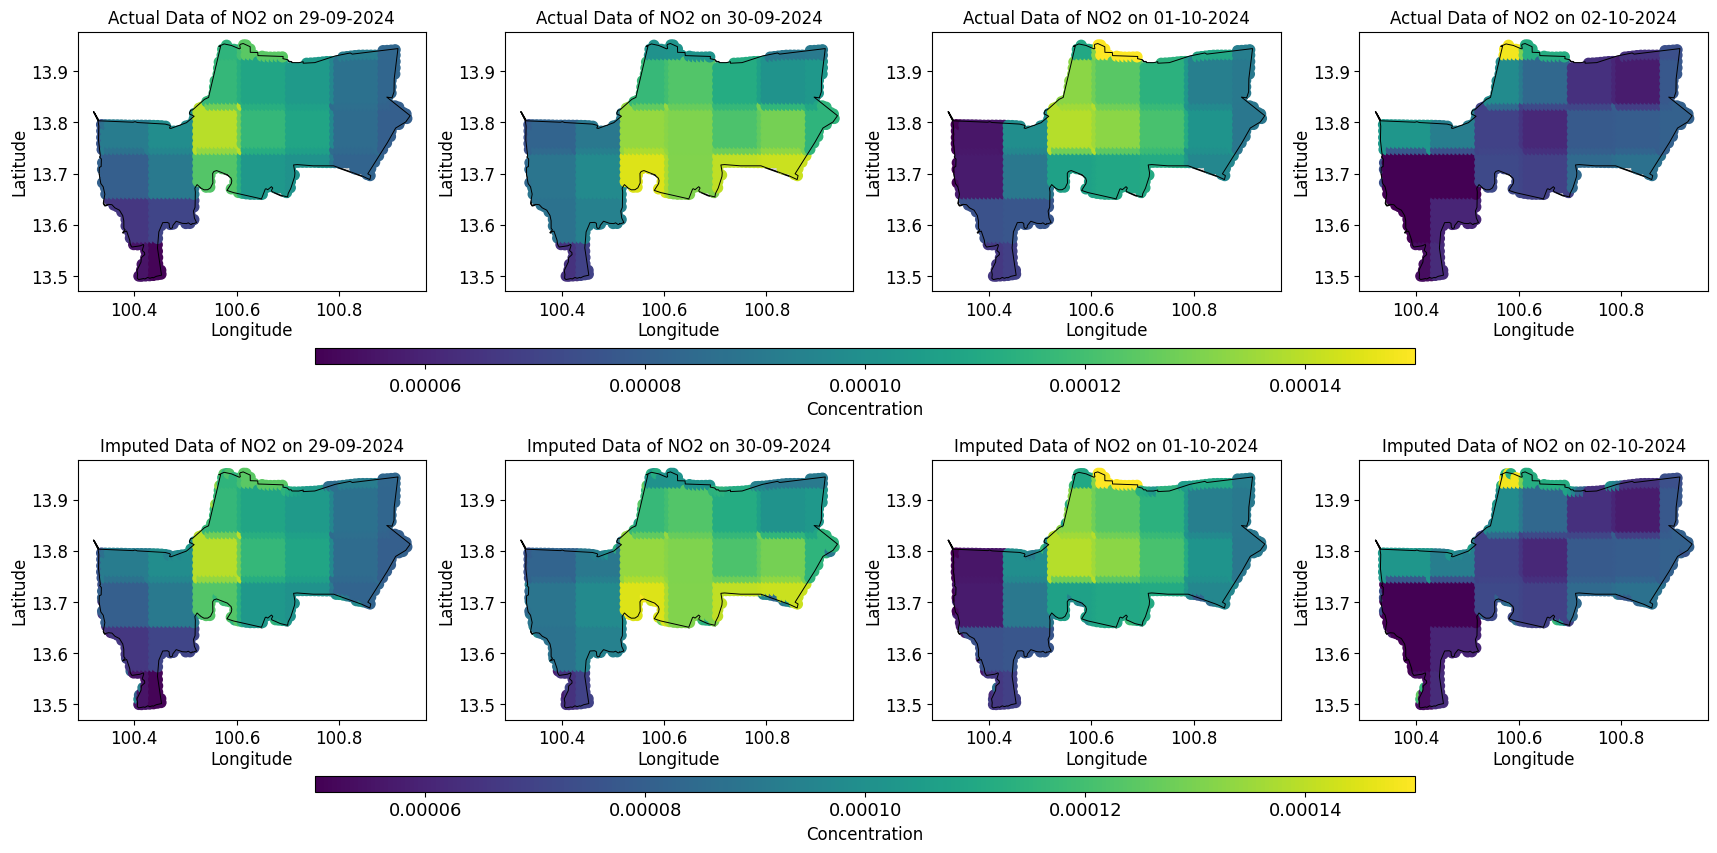

In [ ]:
# @title
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

viridis = plt.cm.viridis(np.linspace(0, 1, 256))
# Define a smooth gradient from yellow to orange to red (HSV-based blending)
yellow_to_red = np.array([
    [253/255, 231/255, 37/255, 1],  # #FDE725
    [1.0, 0.65, 0.0, 1.0],  # orange
    [1.0, 0.0, 0.0, 1.0]    # red
])
n_extend = int(256 * 0.25)

colors = np.vstack((
    viridis,
    np.linspace(yellow_to_red[0], yellow_to_red[-1], n_extend)
))

# Create the final colormap
viridis_to_red = LinearSegmentedColormap.from_list(
    "viridis_yellow_orange_red", colors
)


# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 29
target_month = 9
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
thailand = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
)
bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Actual Data": None, "Imputed Data": None}
vmin, vmax = 5e-5, 1.5e-4

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of NO2 on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


t = 517


/tmp/ipython-input-3376790967.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bangkok['centroid'] = bangkok.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-3376790967.py:75: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/i

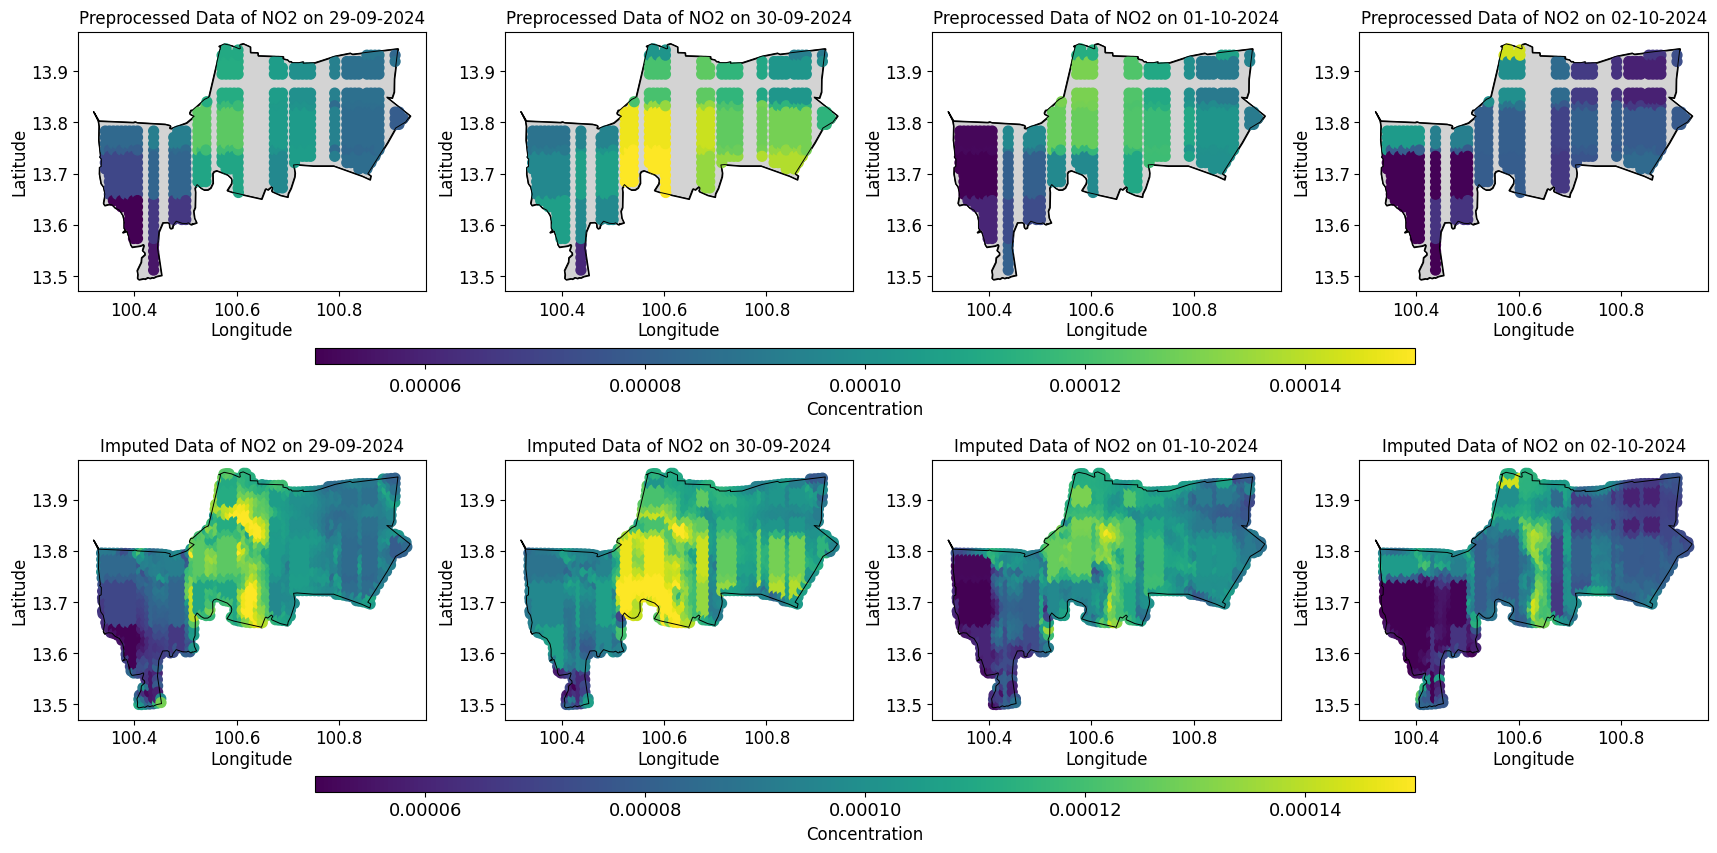

In [ ]:
# @title
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap

viridis = plt.cm.viridis(np.linspace(0, 1, 256))
# Define a smooth gradient from yellow to orange to red (HSV-based blending)
yellow_to_red = np.array([
    [253/255, 231/255, 37/255, 1],  # #FDE725
    [1.0, 0.65, 0.0, 1.0],  # orange
    [1.0, 0.0, 0.0, 1.0]    # red
])
n_extend = int(256 * 0.25)

colors = np.vstack((
    viridis,
    np.linspace(yellow_to_red[0], yellow_to_red[-1], n_extend)
))

# Create the final colormap
viridis_to_red = LinearSegmentedColormap.from_list(
    "viridis_yellow_orange_red", colors
)


# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 29
target_month = 9
target_year = 2024
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
thailand = gpd.read_file(
    'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
)
bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Actual Data": None, "Imputed Data": None}
vmin, vmax = 5e-5, 1.5e-4

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Preprocessed Data"), (df_filtered_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_filtered', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of NO2 on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-1049643652.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1049643652.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1049643652.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

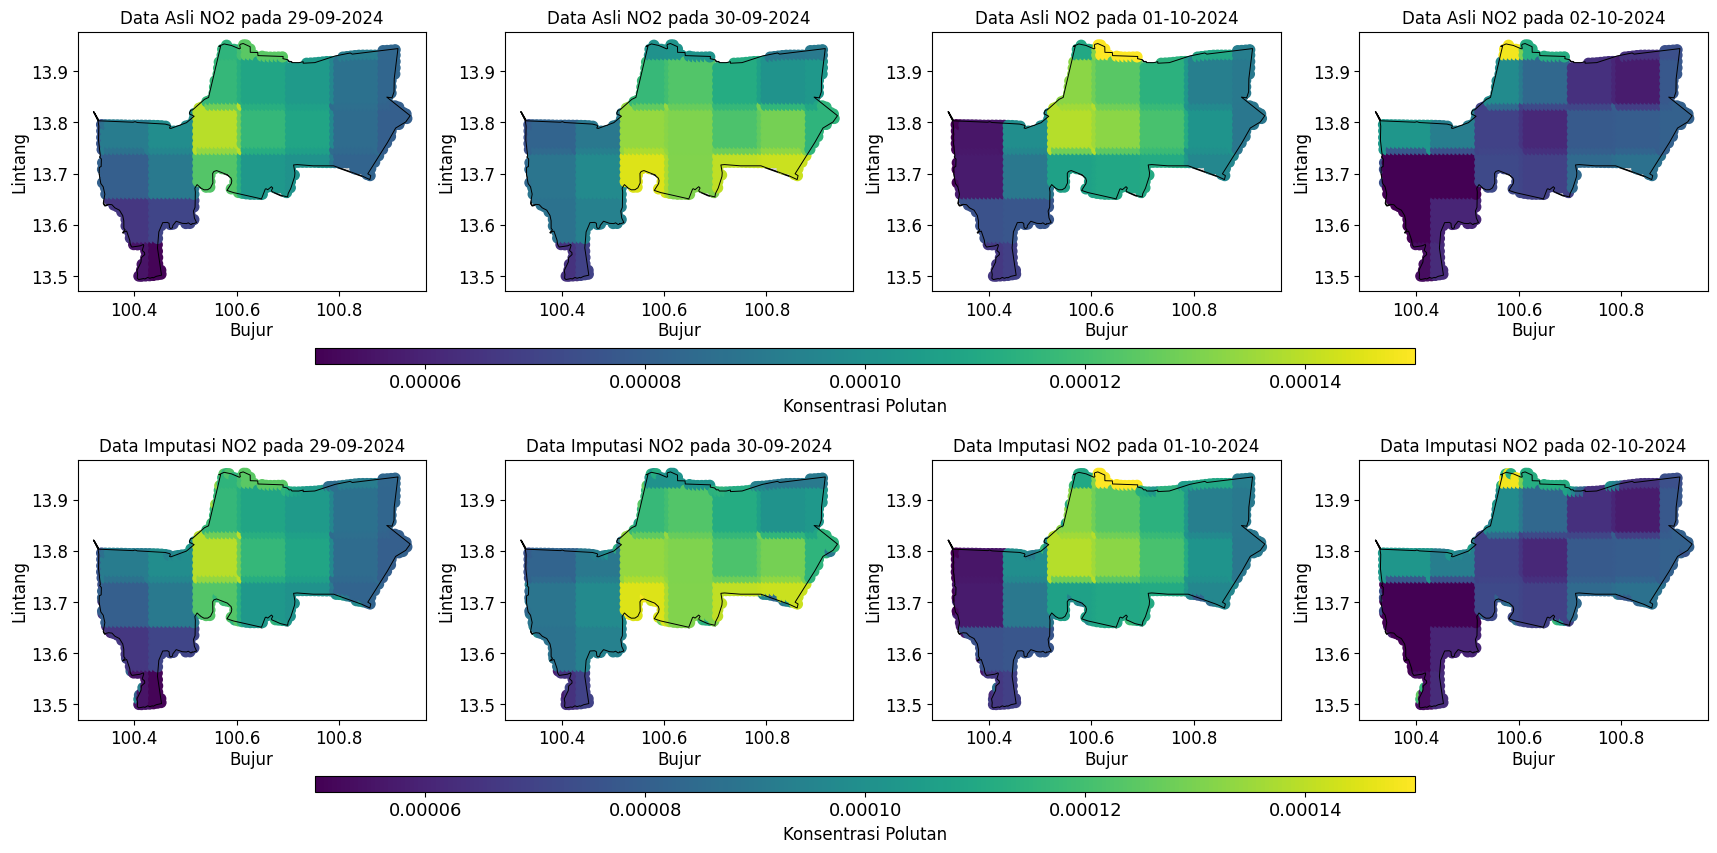

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} NO2 pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-2133118336.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2133118336.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2133118336.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

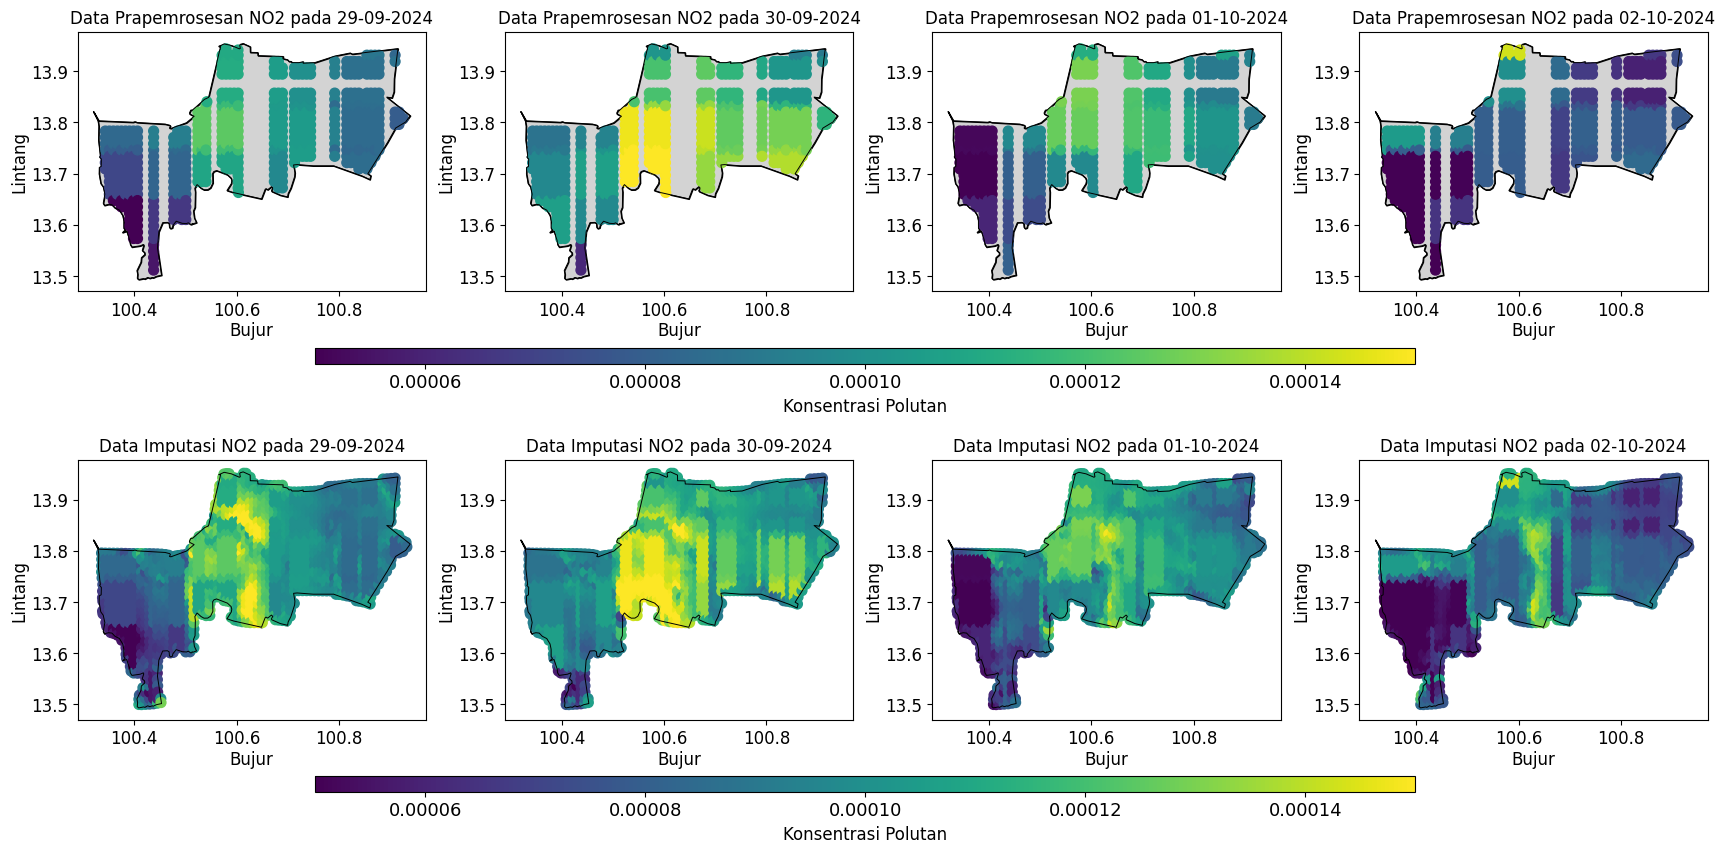

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Data Prapemrosesan"), (df_filtered_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_filtered', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} NO2 pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-1289945036.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1289945036.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1289945036.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

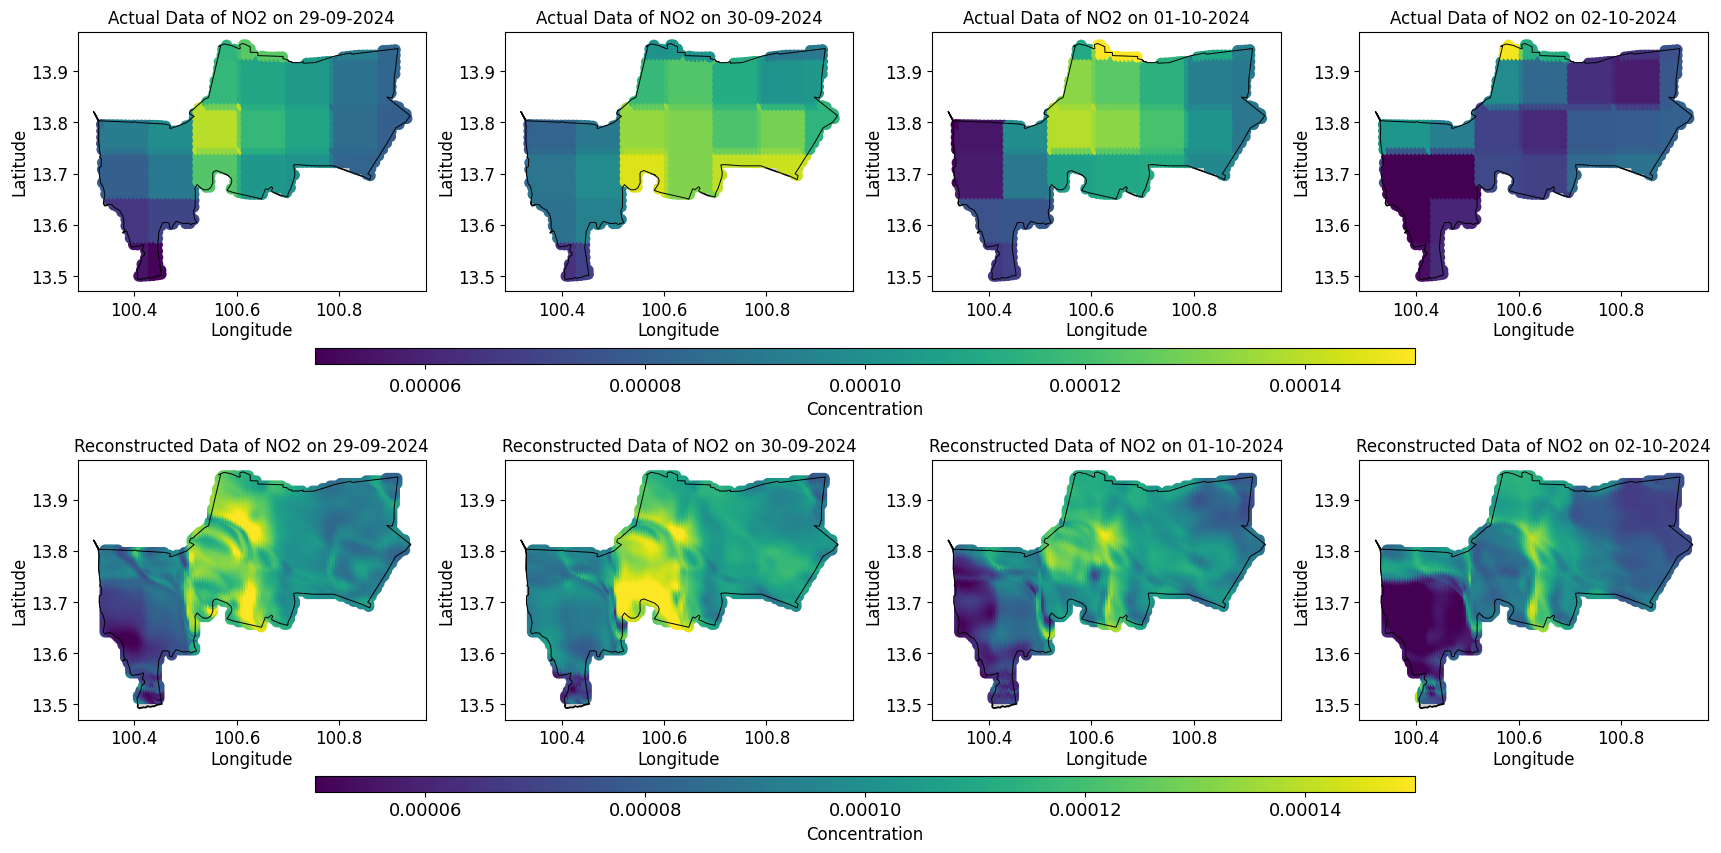

In [ ]:
# @title


predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'NO2_mean','t':'time','x':'x_coord','y':'y_coord'})


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of NO2 on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-565938347.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-565938347.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-565938347.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-

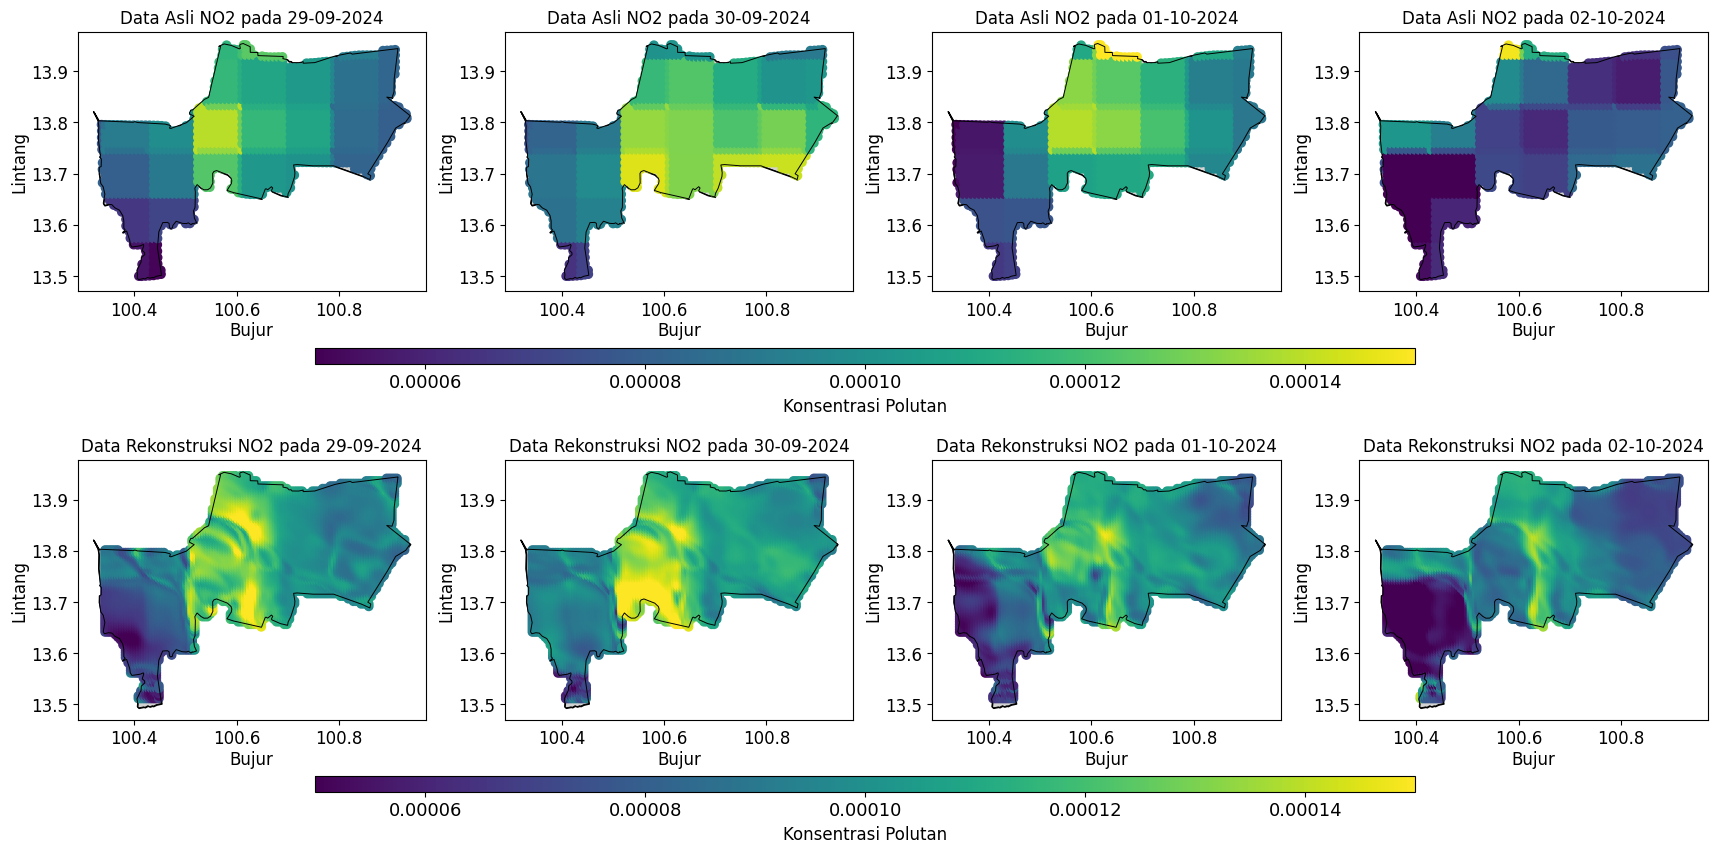

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
                cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable


        ax.set_title(f"{label} NO2 pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


# Fire Wood 18 January 2025

t = 625


/tmp/ipython-input-3060896847.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3060896847.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3060896847.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

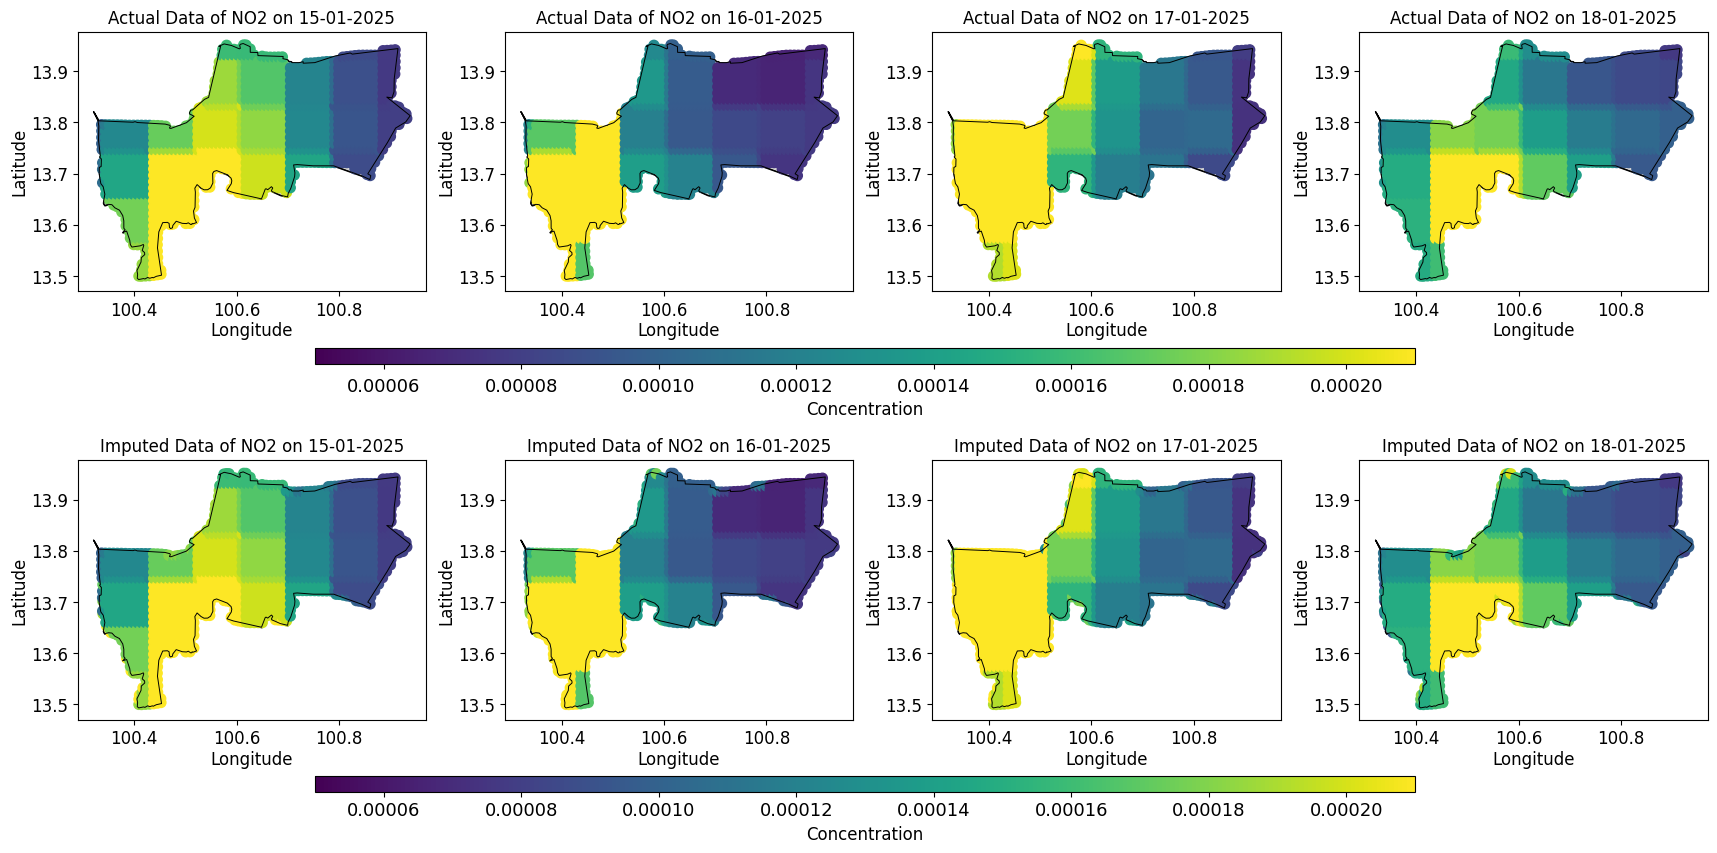

In [ ]:
# @title
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 15
target_month = 1
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
# thailand = gpd.read_file(
#     'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
# )
# bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
# bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 5e-5, 2.1e-4

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (df_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of NO2 on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


t = 625


/tmp/ipython-input-3363239872.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3363239872.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-3363239872.py:54: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

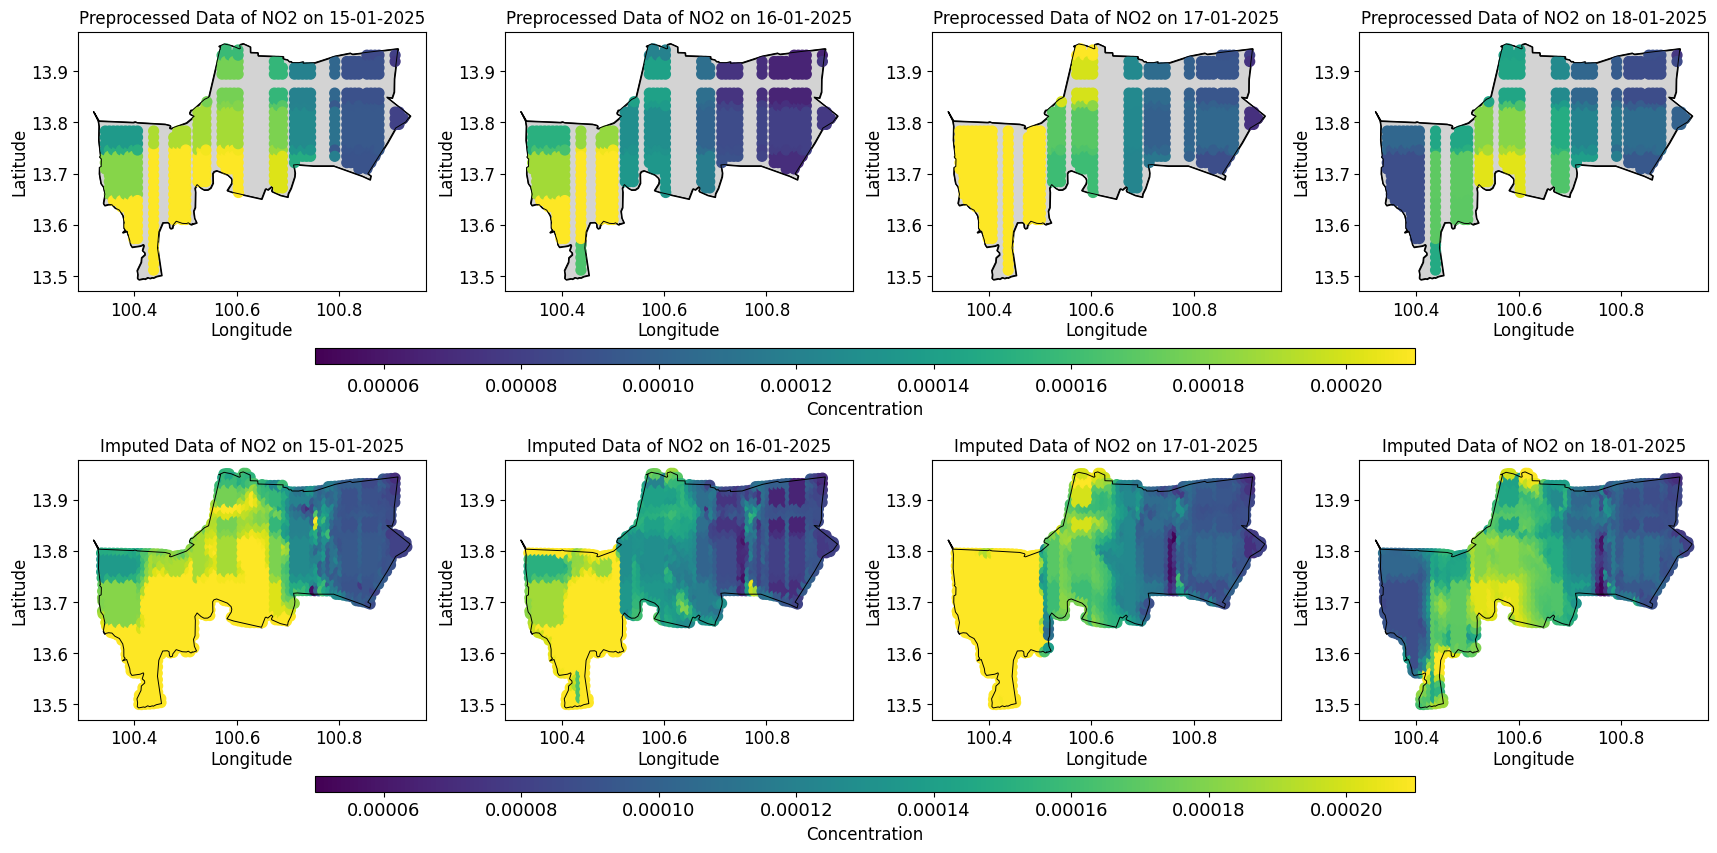

In [ ]:
# @title
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
target_day = 15
target_month = 1
target_year = 2025
target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

# --- Step 3: Load Bangkok shapefile ---
# thailand = gpd.read_file(
#     'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json'
# )
# bangkok = thailand[thailand['NAME_1'] == 'BangkokMetropolis']
# bangkok['centroid'] = bangkok.geometry.centroid


# --- Step 4: Define the offsets you want to compare ---
day_offsets = [0,1,2,3]

# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}
vmin, vmax = 5e-5, 2.1e-4

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Preprocessed Data"), (df_filtered_imputation, "Imputed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_filtered', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of NO2 on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-1049643652.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1049643652.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1049643652.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

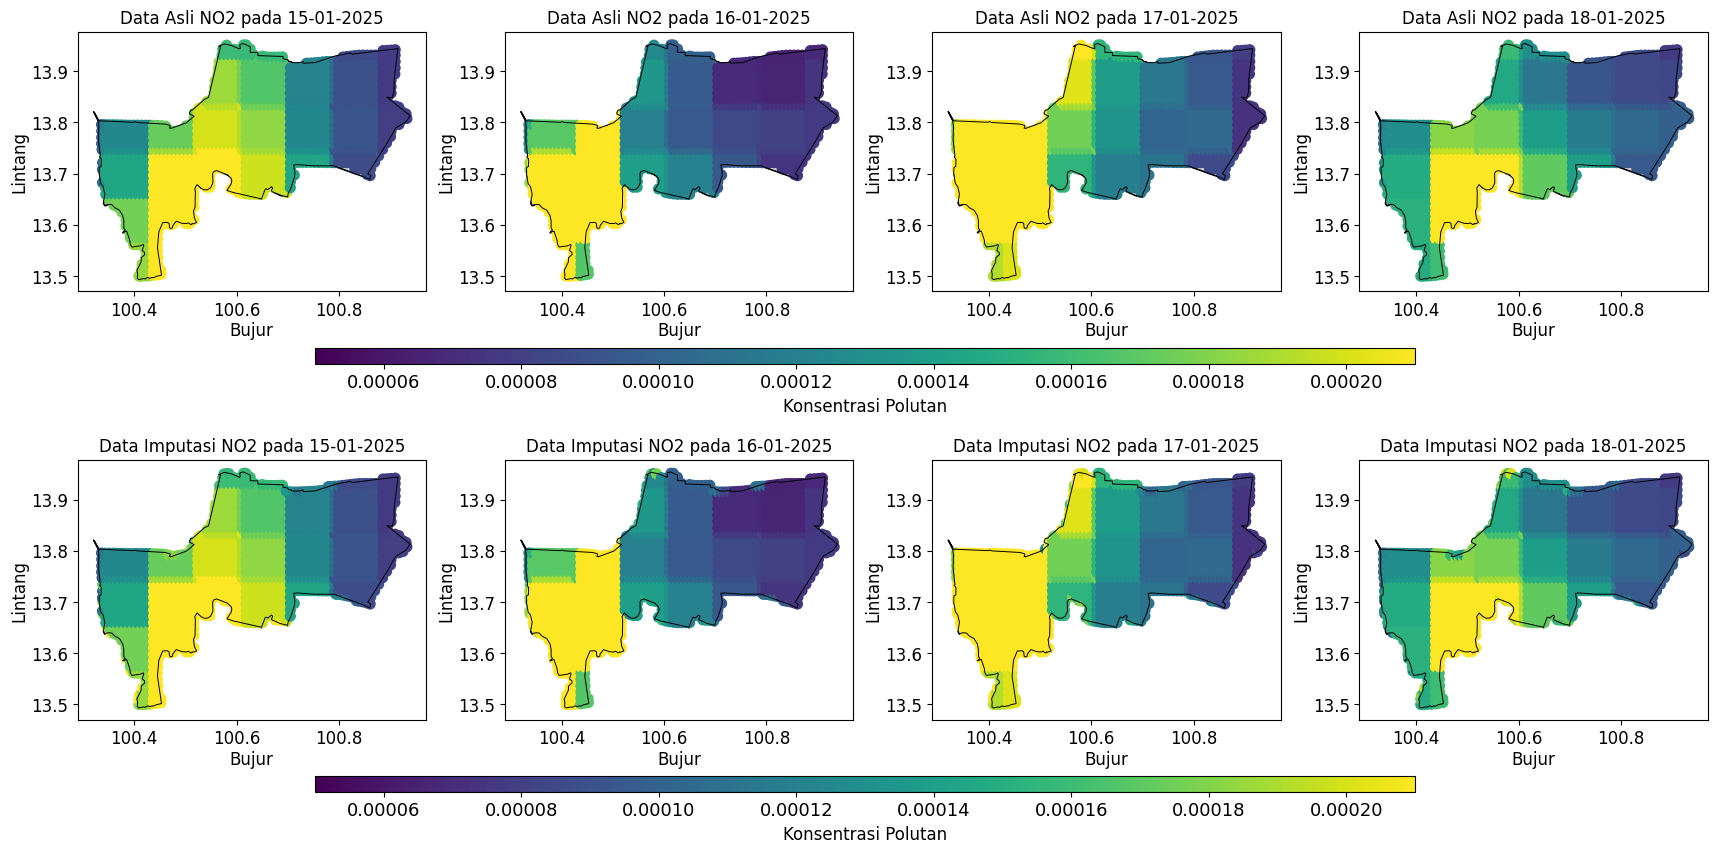

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (df_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} NO2 pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-2133118336.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2133118336.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-2133118336.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

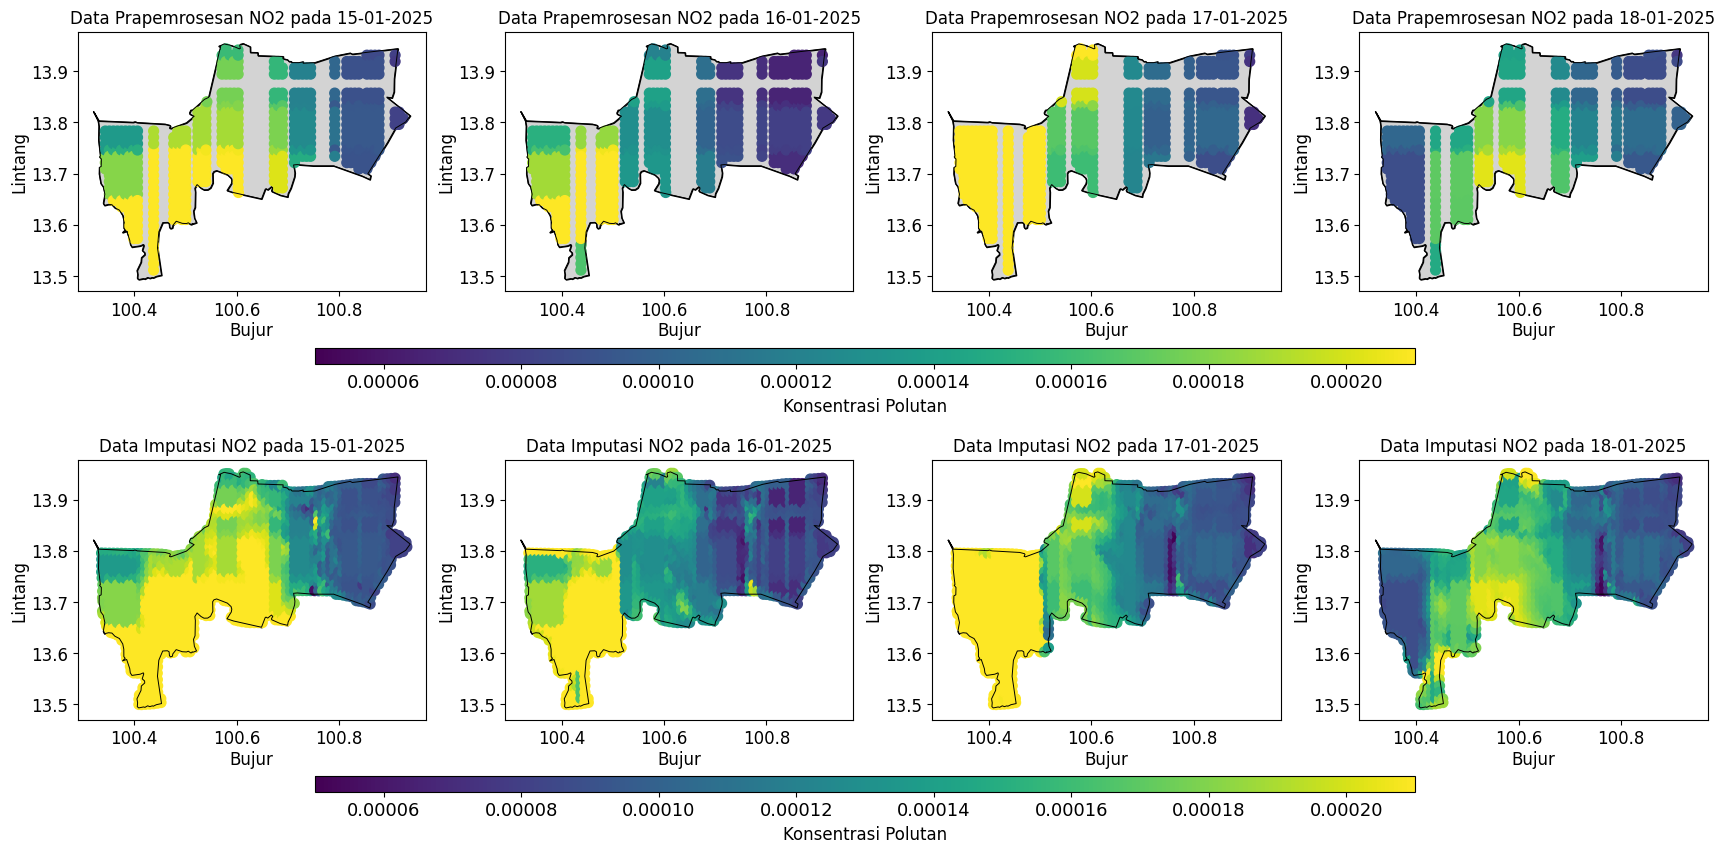

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df_filter, "Data Prapemrosesan"), (df_filtered_imputation, "Data Imputasi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_filtered', ax=ax,
               cmap='viridis',
              vmin=vmin, vmax=vmax, markersize=50

            )
            mappables[label] = mappable


        ax.set_title(f"{label} NO2 pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-1289945036.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1289945036.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-1289945036.py:27: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-inp

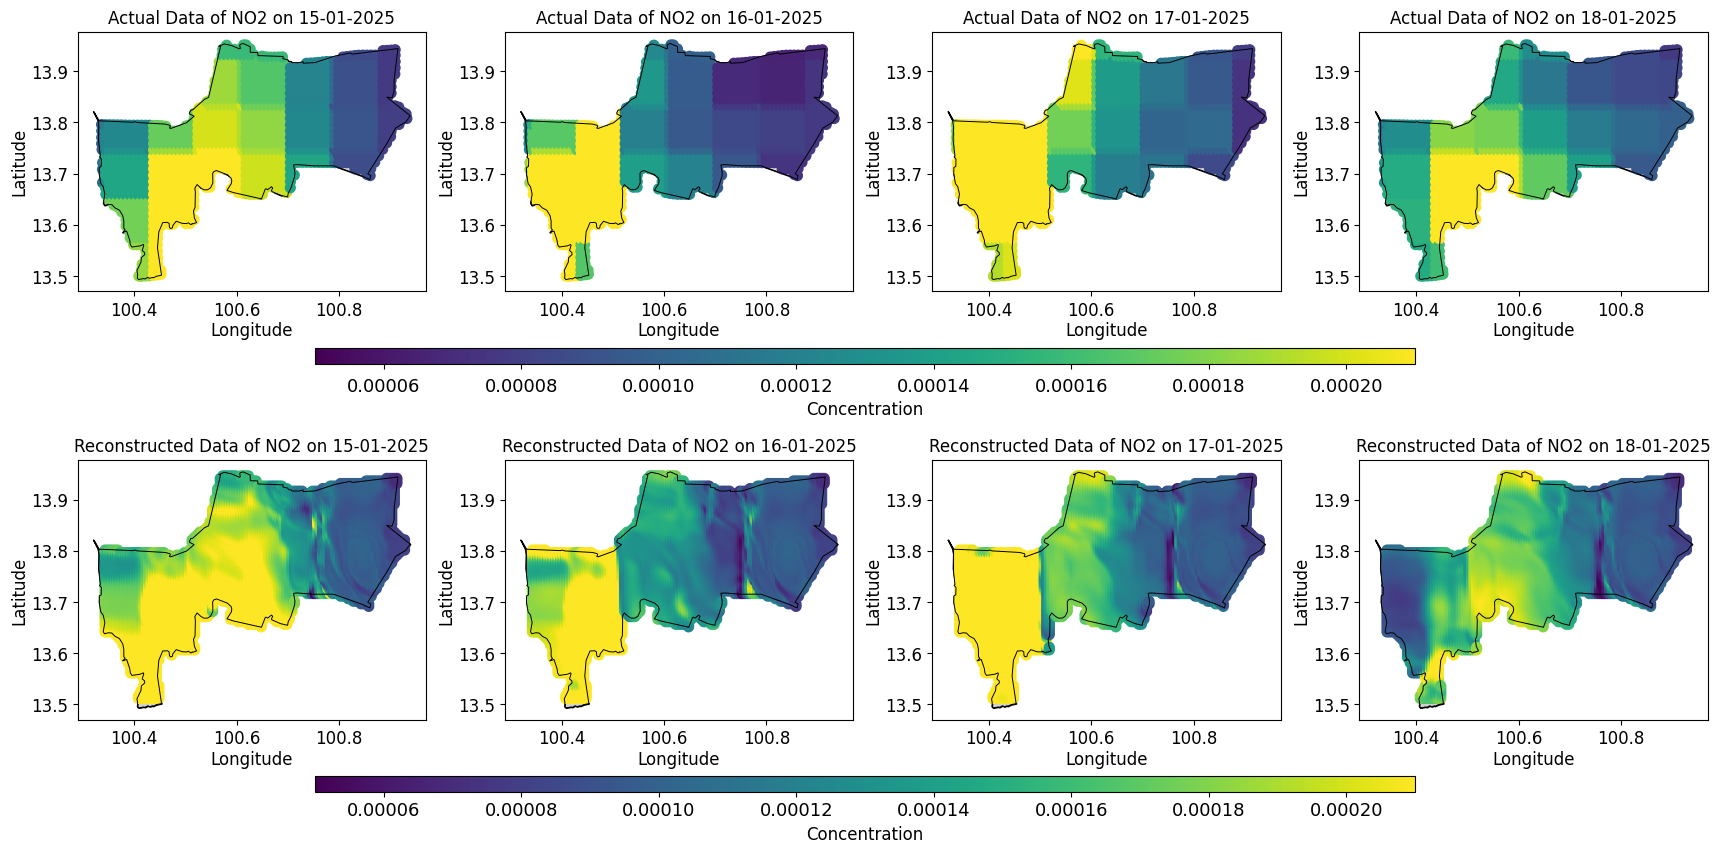

In [ ]:
# @title


predict = prediction_df.copy()
predict = predict.rename(columns={'prediction':'NO2_mean','t':'time','x':'x_coord','y':'y_coord'})


# --- Step 5: Setup figure (rows = dates, cols = 2 for df & df_imputation) ---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Actual Data"), (predict, "Reconstructed Data")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
                cmap='viridis',
                vmin=vmin, vmax=vmax, markersize=50
            )
            mappables[label] = mappable

        ax.set_title(f"{label} of NO2 on {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Longitude", fontsize=12, labelpad=2)
        ax.set_ylabel("Latitude", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Concentration", fontsize=12)
cbar1.ax.tick_params(labelsize=13,pad=6)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Concentration", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()


/tmp/ipython-input-565938347.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-565938347.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-565938347.py:23: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")
/tmp/ipython-input-

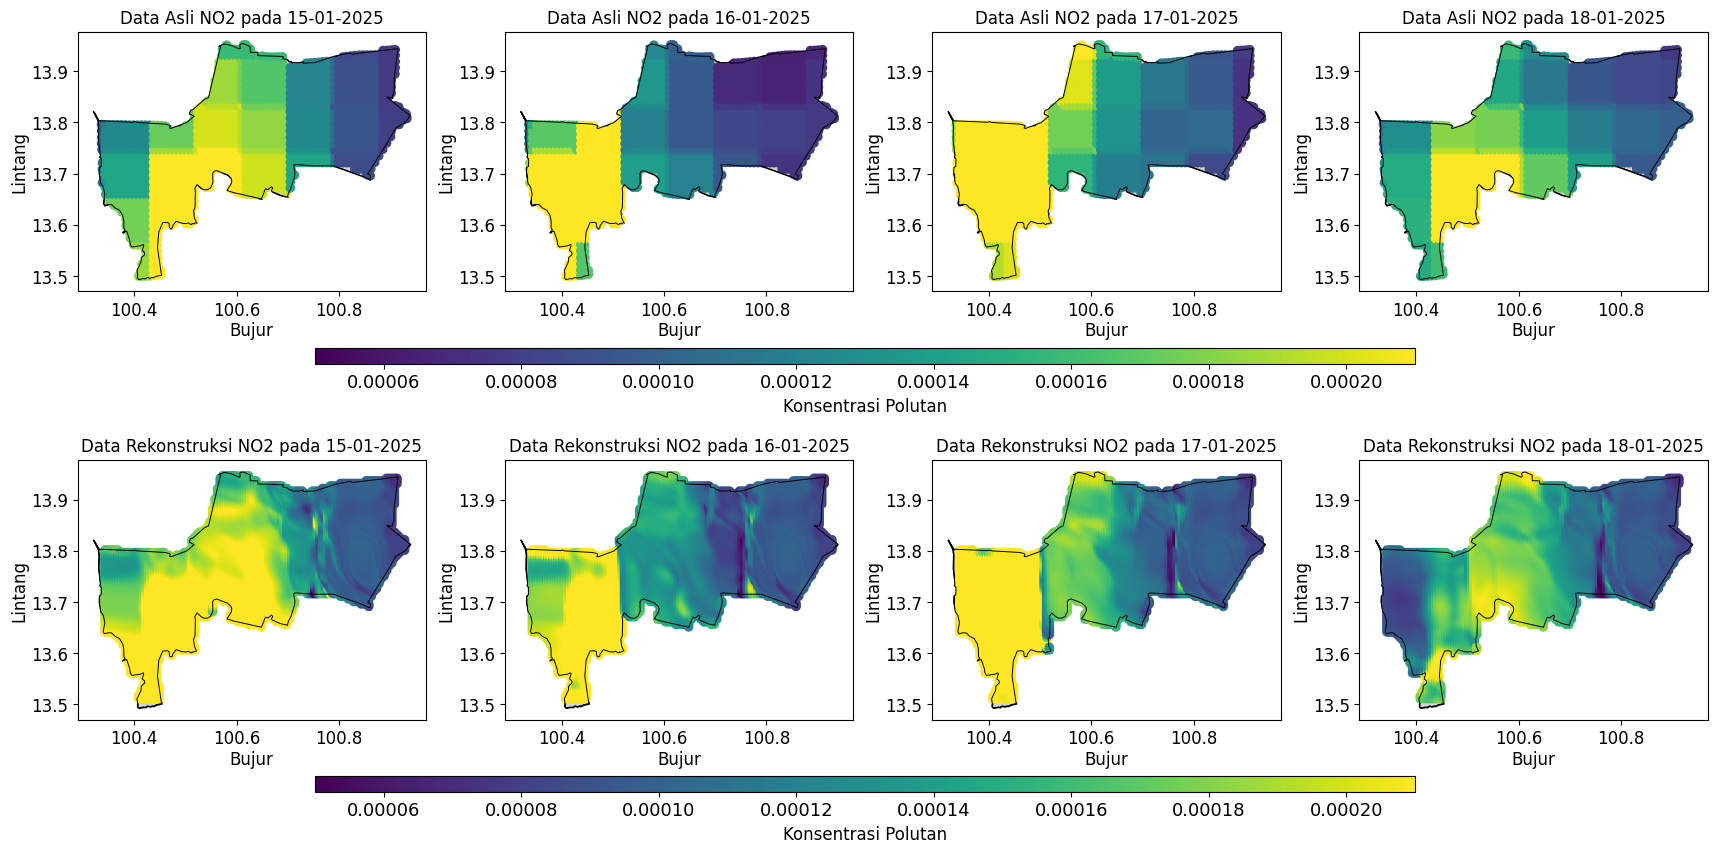

In [ ]:
# @title
# --- Step 5: Setup figure---
fig, axes = plt.subplots(2, len(day_offsets), figsize=(5.5 * len(day_offsets), 8))
if len(day_offsets) == 1:
    axes = axes.reshape(2, 1)  # Ensure axes is always 2D

mappables = {"Data Asli": None, "Data Rekonstruksi": None}

for row_idx, day_offset in enumerate(day_offsets):
    time_to_visualize = t + day_offset
    date_label = (target_date + timedelta(days=day_offset)).strftime('%d-%m-%Y')

    for col_idx, (source_df, label) in enumerate([(df, "Data Asli"), (predict, "Data Rekonstruksi")]):
        ax = axes[col_idx][row_idx]

        df_visualize = source_df[source_df['time'] == time_to_visualize].copy()
        if df_visualize.empty:
            ax.set_title(f"No data for {label} t+{day_offset} ({date_label})", fontsize=12)
            ax.axis('off')
            continue

        geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
        gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
        merged_gdf = gpd.sjoin(gdf, bangkok, how="inner", predicate="within")

        bangkok.plot(ax=ax, color='lightgray', edgecolor='black')
        bangkok.boundary.plot(ax=ax, color='black', linewidth=0.7)

        if not merged_gdf.empty:
            mappable = merged_gdf.plot(
                column='NO2_mean', ax=ax,
                cmap='viridis', vmin=vmin, vmax=vmax
            )
            mappables[label] = mappable


        ax.set_title(f"{label} NO2 pada {date_label}", fontsize=12, pad=6)
        ax.set_xlabel("Bujur", fontsize=12, labelpad=2)
        ax.set_ylabel("Lintang", fontsize=12, labelpad=2)
        ax.tick_params(axis='both', which='major', labelsize=12)

# Create separate colorbars for each row
cbar_ax1 = fig.add_axes([0.25, 0.535, 0.5, 0.02])
cbar_ax2 = fig.add_axes([0.25, 0.0, 0.5, 0.02])

sm1 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cbar1.set_label("Konsentrasi Polutan", fontsize=12)
cbar1.ax.tick_params(labelsize=13)

sm2 = mpl.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
cbar2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cbar2.set_label("Konsentrasi Polutan", fontsize=12)
cbar2.ax.tick_params(labelsize=13)

plt.subplots_adjust(wspace=0.01, hspace=0.65, bottom=0.09, top=0.95)
plt.show()
